# <font color="steelblue">Fundamentos de matemáticas para machine learnig</font>

**Material desarrollado por los [equipos de trabajo de IA4LEGOS](https://ia4legos.umh.es/)**


**Fecha última edición**: 17/06/2026

**Licencia**: <small><a rel="license" href="http://creativecommons.org/licenses/by-sa/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-sa/4.0/88x31.png" /></a><br /></small>

No olvides hacer una copia si deseas utilizarlo. Al usar estos contenidos, aceptas nuestros términos de uso y nuestra política de privacidad.


## <font color="steelblue">Configuración del cuaderno</font>

Para garantizar la funcionalidad completa de este cuaderno, es preciso ejecutar la celda de código a continuación.

In [ ]:
# @title Cargar módulos
# Cargamos módulos de análisis numérico
import numpy as np          # importamos numpy como np
import pandas as pd         # importamos pandas como pd
import math
import random                 # importamos módulo para cáculos matemáticos
from io import StringIO
import sys

# Cargamos módulos de análisis gráficos
from plotnine import *      # importamos módulo para gráficos con ggplot
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid') # Apply a seaborn style with a white background

%config InlineBackend.figure_format = 'retina'

# <font color="darkblue">**Álgebra lineal**</font>

El álgebra lineal es al aprendizaje automático como la harina a la panadería: todo modelo de aprendizaje automático se basa en el álgebra lineal, como todo pastel se basa en la harina. No es el único ingrediente, por supuesto. Los modelos de aprendizaje automático necesitan el cálculo vectorial, la probabilidad y la optimización, como los pasteles necesitan azúcar, huevos y mantequilla. El aprendizaje automático aplicado, al igual que la pastelería, consiste esencialmente en combinar estos ingredientes matemáticos de forma inteligente para crear modelos útiles.

Este documento contiene los fundamentos de álgebra lineal a nivel introductorio para el aprendizaje automático aplicado. Está pensado como una referencia más que como una revisión exhaustiva.

Para mostrar como realizar los cálculos involucrados en Python utilizamos las librerías más habituales como son `numpy` y `Scipy`. Para desarrollos más complejos se aconsjea acudir a las librerías `Pytorch` y `TensorFlow`.

# <font color="darkblue">**Escalares, Vectores, Matrices y Tensores**</font>

El estudio del álgebra lineal implica varios tipos de objetos matemáticos:

**Escalares**: Un escalar es un número único. Normalmente, los escalares se denominan con minúsculas y, cuando los introducimos, especificamos qué tipo de número son. Podemos decir $a \in \mathbb{R}$ para indicar que $a$ es un número real, o $a \in \mathbb{N}$ para indicar que $a$ es un número natural.

In [ ]:
# Definendo un escalar real
a = 7.5
a

7.5

**Vectores**: Un vector es una secuencia ordenada o desordenada de números, de forma que cada uno de ellos se puede identificar según la posición que ocupa en la secuencia. Los vectores se notan mediante una letra minúscula en negrita y cada uno de los elementos se identifica mediante la misma letra y un subíndice en función de la posición que ocupa. De esta forma:

$$\mathbf{x} = [x_1, x_2,...,x_n]$$

representa al vector $\mathbf{x}$  de dimensión $n$ (1 fila y $n$ columnas). En términos de análisis geométrico un vector de dimensión $n$ puede ser visto como las coordenadas de un punto en el espacio $\mathbb{R}^n$.

In [ ]:
# Definimos un vector de dimensión 4
x = np.array([-1.1, 0.0, 3.6, -7.2])
x

array([-1.1,  0. ,  3.6, -7.2])

**Matrices**: Una matriz es una estructura bidimensional de números, donde cada elemento se identifica por dos índices en lugar de uno solo (fila y columna). Solemos dar a las matrices nombres de variables en mayúsculas y en negrita, como $\mathbf{A}$. Si la matriz tiene $m$ filas y $n$ columnas entonces diremos que $\mathbf{A} \in \mathbb{R}^{m\times n}$. En la notación habitual tenemos que:

$$\mathbf{A} =
\begin{bmatrix}
a_{11} & a_{12} & ... & a_{1n}\\
a_{21} & a_{22} & ... & a_{2n}\\
... & ... & ... & ...\\
a_{m1} & a_{m2} & ... & a_{mn}
\end{bmatrix}
$$

representa a la matriz $\mathbf{A}$ de dimensiones $m \times n$ o de forma simplificada escribimos $\mathbf{A} = \{a_{ij}\}_{m,n}$.

En Python podemos definir una matriz mediante la concatenación de los vectores necesarios para alcanzar el número de filas deseado.


In [ ]:
# Definimos una matriz de dimensiones 3X4 (concatenamos tres vectores de dimensión 4)
A = np.matrix([[0.0, 1.0, -2.3, 0.1],
               [1.3, 4.0, -0.1, 0.0],
               [4.1, -1.0, 0.0, 1.7]])
A

matrix([[ 0. ,  1. , -2.3,  0.1],
        [ 1.3,  4. , -0.1,  0. ],
        [ 4.1, -1. ,  0. ,  1.7]])

**Tensores**. Los tensores son la generalización de las matrices o arrays a estructuras de datos con más de dos dimensiones. Los tensores se denotan utilizando la misma nomenclatura que para las matrices pero añadiendo las dimensiones que correspondan. Por ejemplo $\mathbf{A}_{n,m,k}$ representa un array de tres componentes con dimensiones $n$, $m$, y $k$.

In [ ]:
# Definimos un tensor de dimensiones 3X3X3
A=np.array([[[1, 2, 3], [4, 5, 6], [7, 8, 9]],
            [[10, 11, 12], [13, 14, 15], [16, 17, 18]],
            [[19, 20, 21], [22, 23, 24], [25, 26, 27]]])
A

array([[[ 1,  2,  3],
        [ 4,  5,  6],
        [ 7,  8,  9]],

       [[10, 11, 12],
        [13, 14, 15],
        [16, 17, 18]],

       [[19, 20, 21],
        [22, 23, 24],
        [25, 26, 27]]])

# <font color="darkblue">**Vectores y matrices especiales**</font>

Resulta muy habitual utilizar vectores y matrices con estructuras específicas, pero que son de gran utilidad en los cálculos computacionales involucrados en los algoritmos de aprendizaje automático. A continuación se presenta una colección de todos ellos con la función necesaria para su definición en Python.

## <font color="steelblue">Vectores</font>

**Vector de ceros**. Es un vector de dimensión $n$ donde todas sus componenetes toman el valor 0 que denotamos como $\mathbb{0}_n$.

In [ ]:
# Vector de ceros de dimensión 4
x = np.zeros(4)
x

array([0., 0., 0., 0.])

**Vector unitario**. Los vectores unitarios, son vectores compuestos por un solo elemento igual a uno, y el resto a cero. Los vectores unitarios son importantes para entender aplicaciones como las normas. Podemos definir un vector unitario utilizando un vector de ceros. Los vectores unitarios se denotan habitualmente como $\mathbf{u}_i$, donde el subíndice indica la posición del elemento igual a 1.

In [ ]:
# Vector unitario de dimensión 5 con un 1 en la primera posición (u_1)
i = 0; n = 5
ui = np.zeros(n)
ui[i] = 1
ui

array([1., 0., 0., 0., 0.])

**Vector de unos**. Es un vector donde todas su componentes son igual a 1. Estos vectores se denotan como $\mathbb{1}_n$

In [ ]:
# Vector de unos de dimensión 6
np.ones(6)

array([1., 1., 1., 1., 1., 1.])

**Vector aleatorio**. Es un vector donde todas sus componentes son números aleatorios.

In [ ]:
# Vector aleatorio de dimensión 5
np.random.randn(5)

array([ 0.35607721,  0.10401739,  0.18104174, -1.83002142, -1.16685826])

## <font color="steelblue">Matrices</font>

**Matriz de ceros**. Es una matriz donde todos los elementos son iguales a cero. En este caso debemos indicar las filas y columnas de la matriz y la denotamos como $\mathbf{0}_{m,n}$.

In [ ]:
# matriz de ceros con dos filas y tres columnas
np.zeros((2, 3))

array([[0., 0., 0.],
       [0., 0., 0.]])

**Matriz de unos**. Es una matriz con todos sus elementos iguales a 1. Lo denotamos como $\mathbf{1}_{m,n}$.

In [ ]:
# matriz de unos con dos filas y tres columnas
np.ones((2, 3))

array([[1., 1., 1.],
       [1., 1., 1.]])

**Matriz identidad**. Es una matriz cuadrada (mismas filas y columnas) donde los elementos de la diagonal son iguales a 1 y el resto son cero. La matriz identidad de dimensión $n$ se denota por $\mathbf{I}_n$.

In [ ]:
# Matriz identidad de dimensión 3
np.identity(3)

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

**Matriz aleatoria**. Es una matriz donde todos sus elementos son número aleatorios.

In [ ]:
# Matriz aleatoria con dos filas y tres columnas
np.random.randn(2, 3)

array([[ 0.58585489,  0.01152361, -0.55232922],
       [-1.03100381,  0.43847568, -1.74090803]])

**Matriz diagonal**. Es una matriz cuadrada donde los elementos de la diagonal se corresponden con un vector de la misma dimensión que el número de filas de la matriz, y donde el resto de elementos son cero.

In [ ]:
# Matriz diagonal a partir del vector x=[1, 2, 3]
np.diag([1,2,3])

array([[1, 0, 0],
       [0, 2, 0],
       [0, 0, 3]])

**Matriz triangular inferior**. Una matriz cuadrada se dice triangular inferior si todos los elementos por encima de la diagonal son igual a cero. En el caso más sencillo todos los elementos de la diagonal y por debajo de ella son iguales a 1.

In [ ]:
# Matriz tringular inferior de dimensiones 3*3
np.tri(3)

array([[1., 0., 0.],
       [1., 1., 0.],
       [1., 1., 1.]])

**Matriz traspuesta**. La matriz traspuesta de una matriz $\mathbf{A}$, que denotamos por $\mathbf{A}^T$, se obtiene al intercambiar filas y columnas en una matriz.

In [ ]:
A = np.array([[0, 2, 1],
              [1, 4, 2]])
A.T

array([[0, 1],
       [2, 4],
       [1, 2]])

**Matriz simétrica**. Las matrices simétricas son la matrices cuadradas tales que $\mathbf{A} = \mathbf{A}^T$.

**Matriz antidiagonal**. Las matrices con todos los elementos iguales a cero salvo los de la antidiagonal se denomina matriz antidiagonal.

$$\mathbf{A} =
\begin{bmatrix}
0 & 0 & 2\\
0 & 1 & 0\\
-1 & 0 & 0
\end{bmatrix}
$$

# <font color="darkblue">**Operaciones con vectores**</font>

Se presentan a continuación las operaciones algebráicas con vectores.

## <font color="steelblue">Operaciones elementales</font>

**Suma de vectores**. Dados dos vectores de dimensión $n$, $\mathbf{x} = [x_1,...,x_n]$ e $\mathbf{y} = [y_1,...,y_n]$, se define su suma como la suma/diferencia elemento a elemento:

$$\mathbf{x} + \mathbf{y} = [x_1+y_1,...,x_n+y_n]$$


Las propiedades fundamentales que verifican la suma de vectores son conmutatividad y asociatividad.

In [ ]:
# Definición de vectores
x = np.array([1, 3, 5, 7, 9])
y = np.array([0, 2, 4, 6, 8])
suma = x + y
print('La suma es:',suma)
resta = x - y
print('La resta es:',resta)

La suma es: [ 1  5  9 13 17]
La resta es: [1 1 1 1 1]


**Multiplicación por un escalar**. Dado un escalar $a \in \mathbb{R}$ y un vector $\mathbf{x} = [x_1,...,x_n] \in \mathbb{R}^n$, se define el producto entre ambos como:

$$a\mathbf{x} = [ax_1,...,ax_n]$$

Dados dos escalares $a \in \mathbb{R}$ y $b \in \mathbb{R}$, y dos vectores $\mathbf{x} \in \mathbb{R}^n$ e $\mathbf{y} \in \mathbb{R}^n$se verifican las propiedades siguientes:

* $(ab)\mathbf{x} = a(b\mathbf{x})$
* $(a + b)\mathbf{x} = a\mathbf{x} + b\mathbf{x}$
* $a(\mathbf{x} + \mathbf{y}) =a\mathbf{x} + a\mathbf{y}$


In [ ]:
x = np.array([1, 3, 5, 7, 9])
a = 2
print(a*x)

[ 2  6 10 14 18]


**Vector traspuesto**. Dado un vector $\mathbf{x} = [x_1,...,x_n] \in \mathbb{R}^n$ se define su trapuesto, denotado por $\mathbf{x}^{T}$, como el intercambio de filas por columnas, es decir:

$$\mathbf{x}^{T} =
\begin{bmatrix}
x_1\\
x_2\\
...\\
x_n
\end{bmatrix}$$

**Producto interno o producto escalar**. Dados dos  vectores $\mathbf{x} \in \mathbb{R}^n$ e $\mathbf{y} \in \mathbb{R}^n$, se define el producto interno o producto escalar como:

$$<\mathbf{x},\mathbf{y}> = \mathbf{x}\mathbf{y} = \sum_{i=1}^n x_iy_i.$$

In [ ]:
# Definición de vectores
x = np.array([1, 3, 5, 7, 9])
y = np.array([0, 2, 4, 6, 8])
# Producto escalar
np.inner(x, y)

np.int64(140)

## <font color="steelblue">Norma de un vector</font>

La medición de vectores es otra operación importante en las aplicaciones de aprendizaje automático. Intuitivamente, podemos pensar en la norma o la longitud de un vector como la distancia entre su "origen" y su "final". Las normas mapean vectores a valores no negativos. En este sentido son funciones que asignan la longitud a un vector. A continuación, mostramos las propiedades que debe verificar una norma para ser considerada como tal y presentamos los tipos más utilizados. En todos los casos consderamos un vector $\mathbf{x} \in \mathbb{R}^n$.


Dado un escalar $a$ y dos vectores $\mathbf{x}$ e $\mathbf{y}$, las propiedades que debe cumplir una función para considerarse una norma son:

1. Homogeneidad absoluta

$$\|a\mathbf{x}\| = |a|\|\mathbf{x}\|$$

2. Desigualdad triangular

$$\|\mathbf{x} + \mathbf{y}\| \leq \|\mathbf{x}\| + \|\mathbf{y}\|$$

3. Definida positiva

$$\|\mathbf{x}\| \geq 0$$
$$\|\mathbf{x}\| =0 \Leftrightarrow \mathbf{x} = \mathbf{0}$$




### <font color="steelblue">Norma euclídea</font>

La norma euclidiana o norma $L_2$ es una de las normas más populares en el aprendizaje automático. Su uso está tan extendido que a veces se denomina simplemente "la norma" de un vector. Se define como:

$$\|\mathbf{x}\|_2 = \sqrt{ \sum_{i=1}^n x^2_i } = \sqrt{<x,x>}$$

In [ ]:
# Definición de vector
x = np.array([1, 3, 5, 7, 9])
# norma euclídea
np.linalg.norm(x, 2)

np.float64(12.84523257866513)

A partir de ahora identificaremos la norma $L_2$ como $\|\mathbf{x}\|_2 = \|\mathbf{x}\|$

### <font color="steelblue">Norma Manhattan</font>

La norma de Manhattan o $L_1$ recibe su nombre por analogía con la medición de distancias al moverse en Manhattan, Nueva York. Como Manhattan tiene forma de cuadrícula, la distancia entre dos puntos cualesquiera se mide moviéndose en líneas verticales y horizontales (en lugar de diagonales como en la norma euclidiana). Se define como:

$$\|\mathbf{x}\|_1 = \sum_{i=1}^n |x_i|,$$

donde $|x_i|$ es el valor absoluto de la componente $i$. Se prefiere la norma $L_1$ cuando se discrimina entre elementos que son exactamente cero y elementos que son pequeños pero no cero.

In [ ]:
# Definición de vector
x = np.array([1, 3, 5, 7, 9])
# norma manhattan
np.linalg.norm(x, 1)

np.float64(25.0)

### <font color="steelblue">Norma máxima</font>

La norma máxima o norma del infinito es simplemente el valor absoluto del mayor elemento del vector. Se define como:

$$\|\mathbf{x}\|_{\infty} = \underset{i}{max}  |x_i|,$$

In [ ]:
# Definición de vector
x = np.array([1, 3, 5, 7, 9])
# norma manhattan
np.linalg.norm(x, np.inf)

np.float64(9.0)

# <font color="darkblue">**Operaciones con matrices**</font>

Se presentan a continuación las principales operaciones que se pueden realizar con matrices.

## <font color="steelblue">Operaciones elementales</font>

**Suma**. Dadas dos matrices $\mathbf{A} = \{a_{ij}\}_{m,n}$ y $\mathbf{B} = \{b_{ij}\}_{m,n}$ se define la suma de ambas como:

$$\mathbf{A} + \mathbf{B} =
\begin{bmatrix}
a_{11} + b_{11} & ... & a_{1n}+b_{1n}\\
...&...&...\\
a_{m1}+b_{m1} & ... & a_{mn}+b_{mn}
\end{bmatrix}
$$

In [ ]:
# Definimos matrices
A = np.array([[0, 2],
              [1, 4]])
B = np.array([[3, 1],
              [-3, 2]])
# Suma
np.add(A, B)
# Se puede hacer directamente como A+B

array([[ 3,  3],
       [-2,  6]])

**Producto por un escalar**. Sea un escalar $k$ y una matriz $\mathbf{A} = \{a_{ij}\}_{m,n}$. Se define el producto de la matriz por un escalar como el producto de cada uno de los elementos de la matriz por el escalar:

$$k\mathbf{A} =
\begin{bmatrix}
ka_{11}& ... & ka_{1n}\\
...&...&...\\
ka_{m1} & ... & ka_{mn}
\end{bmatrix}
$$

o de forma abreviada como $k\mathbf{A} = \{ka_{ij}\}_{m,n}$.

In [ ]:
# Escalar y matriz
k = 2
A = np.array([[1, 2],
              [3, 4]])
# Producto
np.multiply(k, A)
# también se puede hacer como k*A

array([[2, 4],
       [6, 8]])

**Producto matricial**. La multiplicación de matrices tiene ciertas características especiales. Para poder realizar el cálculo el número de columnas de la primera matriz tiene que ser igual al número de filas de la segunda matriz. Dadas dos matrices $\mathbf{A} = \{a_{ij}\}_{m,n}$ y $\mathbf{B} = \{b_{ij}\}_{n,p}$ una forma de ver la multiplicación matricial es tomando una serie de productos donde multiplicamos: la 1ª columna de A por la 1ª fila de B, la 2ª columna de A por la 2ª fila de B, hasta la enésima columna de A por la enésima fila de B. De esta forma:

$$AB =
\begin{bmatrix}
\sum_{l=1}^n a_{1l}b_{l1} & ... & \sum_{l=1}^n a_{1l}b_{lp}\\
...&...&...\\
\sum_{l=1}^n a_{ml}b_{l1} & ... & \sum_{l=1}^n a_{ml}b_{lp}
\end{bmatrix}
$$

La propiedades del producto matricial son:

1. Asociatividad: $(\mathbf{A}\mathbf{B})\mathbf{C} = \mathbf{A}(\mathbf{B}\mathbf{C})$
2. Asociatividad con multiplicación escalar: $k(\mathbf{A}\mathbf{B})=(k\mathbf{A})\mathbf{B}$
3. Distributiva con la suma: $\mathbf{A}(\mathbf{B}+\mathbf{C})=\mathbf{A}\mathbf{B}+\mathbf{A}\mathbf{C}$
4. Traspuesta del producto: $(\mathbf{A}\mathbf{B})^{T} = \mathbf{B}^{T}\mathbf{A}^{T}$

In [ ]:
# Definimos matrices
A = np.array([[0, 2],
              [1, 4]])
B = np.array([[3, 1],
              [-3, 2]])
# Producto
np.dot(A,B)
# Se puede hacer directamente como A@B

array([[-6,  4],
       [-9,  9]])

**Producto Hadamard o elemento a elemento**. Dadas dos matrices $\mathbf{A} = \{a_{ij}\}_{m,n}$ y $\mathbf{B} = \{b_{ij}\}_{n,p}$ el producto elemento a elemento o producto de Hadamard es la multiplicación de cada elemento de la matriz $\mathbf{A}$ por su correspondiente elemento de la matriz $\mathbf{B}$:

$$\mathbf{A} \odot \mathbf{B} =
\begin{bmatrix}
a_{11}b_{11} & ... & a_{1n}b_{1n}\\
...&...&...\\
a_{m1}b_{m1} & ... & a_{mn}b_{mn}
\end{bmatrix}
$$

In [ ]:
# Definimos matrices
A = np.array([[0,2],
              [1,4]])
B = np.array([[3,1],
              [-3,2]])
# Producto hadamard
np.multiply(A,B)

array([[ 0,  2],
       [-3,  8]])

## <font color="steelblue">Norma de una matriz</font>

Al igual que con los vectores, podemos medir el tamaño de una matriz calculando su norma. Hay múltiples formas de definir la norma de una matriz, siempre que satisfaga las mismas propiedades definidas para las normas de los vectores: (1) absolutamente homogénea, (2) desigualdad triangular, (3) definida positiva. En nuestro caso mostramos las más utilizadas.

### <font color="steelblue">Norma de Frobenius</font>

La norma de Frobenius es una norma obtenida elemento a elemento que lleva el nombre del matemático alemán Ferdinand Georg Frobenius. Denotamos esta norma como $\|\mathbf{A}\|_F$. Se puede considerar esta norma como la conversión de la matriz en un vector. Por ejemplo, una matriz de 3×3 se convertiría en un vector con $n=9$ entradas, del cual obtenemos a norma. Dada una matriz $\mathbf{A} = \{a_{ij}\}_{m,n}$ definimos la norma de Frobenius como:

$$\|\mathbf{A}\|_F = \sqrt{\sum_{i=1}^m \sum_{j=1}^n a_{ij}^2}$$

In [ ]:
# Definimos la matriz
A = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]])
# Norma Frobenius
np.linalg.norm(A, 'fro')

np.float64(16.881943016134134)

### <font color="steelblue">Norma máxima</font>

La norma máxima o norma infinita de una matriz es igual a la mayor suma del valor absoluto de los vectores de las filas. Dada una matriz $\mathbf{A} = \{a_{ij}\}_{m,n}$ definimos la norma máxima, que denotamos por $\|\mathbf{A}\|_{max}$, como:

$$\|\mathbf{A}\|_{max} = \underset{i}{max} \sum_{j=1}^n |a_{ij}|$$


In [ ]:
# Definimos la matriz
A = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]])
# Calculamos la norma
np.linalg.norm(A, np.inf)

np.float64(24.0)

# <font color="darkblue">**Características de una matriz**</font>

Existen diferentes cálculos numéricos a partir de una matriz que nos permiten caracterizarla.

## <font color="steelblue">Rango, traza, y determinante</font>

**Rango**. Dada una matriz $\mathbf{A} = \{a_{ij}\}_{m,n}$ se define el rango de $\mathbf{A}$, que denotamos por $rank(\mathbf{A})$, como el número máximo de filas o columnas linealmente independientes.

In [ ]:
# Definimos la matriz
A = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]])
# Calculamos rango
np.linalg.matrix_rank(A)

np.int64(2)

**Traza**. Dada una matriz cuadrada $\mathbf{A} = \{a_{ij}\}_{m,m}$ se define la traza de $\mathbf{A}$, que denotamos por $tr(\mathbf{A})$, como la suma de los elementos de la diagonal:

$$tr(\mathbf{A}) = \sum_{i=1}^m a_{ii}$$

In [ ]:
# Definimos la matriz
A = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]])
# Calculamos la traza
np.trace(A)

np.int64(15)

**Determinante**. Dada una matriz cuadrada $\mathbf{A} = \{a_{ij}\}_{m,m}$ el determinante de $\mathbf{A}$, que denotamos por $det(\mathbf{A})$ o $|\mathbf{A}|$, es un importante concepto del algebra matricial. Es un indicativo muy rápido para identificar si el conjunto de vectores (por filas o columnas) que forman la matriz son linealmente independientes. Si el determinate es 0 hay filas o columnas linealmente dependientes, mientras que si es distinto de cero todas las filas o columnas son linealmente independentes.

In [ ]:
# Definimos la matriz
A = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]])
# Calculamos el determinante
np.linalg.det(A)

np.float64(0.0)

## <font color="steelblue">Matriz inversa y g-inversa</font>

Dada una matriz cuadrada $\mathbf{A} = \{a_{ij}\}_{n,n}$, se define la inversa de dicha matriz, y se denota por $\mathbf{A}^{-1}$, a la matriz que al multiplicar por $\mathbf{A}$ nos da la matriz identidad, es decir:

$$\mathbf{A}^{-1}\mathbf{A} = \mathbf{A}\mathbf{A}^{-1} = \mathbf{I}_n$$

La matriz inversa nos permite resolver los sistemas de ecuaciones lineales de la forma:

$$\mathbf{A}\mathbf{x} = \mathbf{y}$$

ya que

$$\mathbf{x} = \mathbf{A}^{-1}\mathbf{y}$$

In [ ]:
# Definimos matriz
A = np.array([[1, 2, 1],
              [4, 4, 5],
              [6, 7, 7]])
# Obtenemos inversa
Ainv = np.linalg.inv(A)
Ainv

array([[-7., -7.,  6.],
       [ 2.,  1., -1.],
       [ 4.,  5., -4.]])

Verificamos la propiedad

In [ ]:
# Ajustamos decimales por los ajustes numéricos
np.round(np.dot(Ainv,A))

array([[ 1.,  0.,  0.],
       [ 0.,  1., -0.],
       [ 0., -0.,  1.]])

Un concepto más general es el de matriz g-inversa $A^-$ que verifica:

$$AA^-A=A$$


In [ ]:
# Definimos matriz
A = np.array([[1, 2, 1],
              [4, 4, 5],
              [6, 7, 7]])
# Obtenemos inversa
Aginv = np.linalg.pinv(A)
Aginv

array([[-7., -7.,  6.],
       [ 2.,  1., -1.],
       [ 4.,  5., -4.]])

Verificamos la definición de g-inversa

In [ ]:
A@Aginv@A

array([[1., 2., 1.],
       [4., 4., 5.],
       [6., 7., 7.]])

Utilizamos la pseudo inversa cuando no es posible obtener la matriz inversa de forma directa.

## <font color="steelblue">Propiedades rango, traza, y determinante</font>

Dadas las matrices $\mathbf{A} = \{a_{ij}\}_{n,n}$, $\mathbf{B} = \{b_{ij}\}_{n,n}$, y $k \in \mathbb{R}$ se verifica que:

* $tr(\mathbf{A}+\mathbf{B}) = tr(\mathbf{A}) + tr(\mathbf{B})$

* $tr(k\mathbf{A})= ktr(\mathbf{A})$

* $|k\mathbf{A}| = k^n|\mathbf{A}|$

* $|\mathbf{A}\mathbf{B}|= |\mathbf{B}\mathbf{A}|=|\mathbf{A}||\mathbf{B}|$

* Si $rank(\mathbf{A})=n \Leftrightarrow \mathbf{A} \text{ es no singular}$

* $|\mathbf{A}^{-1}| =|\mathbf{A}|^{-1}$

Dadas las matrices $\mathbf{A} = \{a_{ij}\}_{n,p}$ y $\mathbf{B} = \{b_{ij}\}_{p,n}$, se verifica que:

* $tr(\mathbf{A}\mathbf{B})=tr(\mathbf{B}\mathbf{A})$

* $rank(\mathbf{A})=min(n,p)$

* $rank(\mathbf{A})\geq 0$

* $rank(\mathbf{A})=rank(\mathbf{A}^{T})$

* $rank(\mathbf{A}^{T}\mathbf{A})=rank(\mathbf{A})$

* $rank(\mathbf{A}+\mathbf{B}) \leq rank(\mathbf{A})+rank(\mathbf{B})$

* $rank(\mathbf{A}\mathbf{B}) \leq min(rank(\mathbf{A}),rank(\mathbf{B}))$

Dadas las matrices $\mathbf{A} = \{a_{ij}\}_{n,p}$, $\mathbf{B} = \{b_{ij}\}_{p,q}$ y $\mathbf{C} = \{c_{ij}\}_{q,n}$, se verifica que:

* $tr(\mathbf{A}\mathbf{B}\mathbf{C})=tr(\mathbf{B}\mathbf{C}\mathbf{A}) = tr(\mathbf{C}\mathbf{A}\mathbf{B})$

* $rank(\mathbf{A}\mathbf{B}\mathbf{C}) = rank(\mathbf{B})$ cuando $\mathbf{A}$ y $\mathbf{C}$ son no singulares

## <font color="steelblue">Valores y vectores propios</font>

Dada una matriz $\mathbf{A} = \{a_{ij}\}_{n,n}$ se definen los valores propios de de dicha matriz como las p-raíces, $\lambda_1,...,\lambda_n$, de la ecuación característica:

$$|\mathbf{A}-\mathbf{\lambda} \mathbf{I}_n| = 0,$$

donde $\mathbf{\lambda}=(\lambda_1,...,\lambda_n)$.

Los $n$ vectores propios de la matriz $\mathbf{A}$, $\mathbf{v}_1,...,\mathbf{v}_n$, se obtienen a partir de los $n$ valores propios al resolver el sistema:

$$\mathbf{A}\mathbf{v} = \mathbf{\lambda} \mathbf{v}$$

donde $\mathbf{v}$ es una matriz donde las columnas corresponde a cada uno de los $n$ vectores propios de $\mathbf{A}$.

In [ ]:
# Creamos una matriz
A = np.array([[2, 1],
              [0, 3]])

# Obtenemos valores y vectores propios
val, vec = np.linalg.eig(A)
# En formato complejo
print("Valores propios:")
print(val)
print("\n Vectores propios:")
print(vec)

Valores propios:
[2. 3.]

 Vectores propios:
[[1.         0.70710678]
 [0.         0.70710678]]


Los valores propios de una matriz son una herramienta muy importante ya que nos permiten relacionar la traza y el determinante de una matriz con dichos valores. De hecho, dada una matriz $\mathbf{A} = \{a_{ij}\}_{n,n}$ si consideramos el vector formado por los valores propios $\mathbf{\lambda}= [\lambda_1,...,\lambda_n]$ de forma que construímos una matriz diagonal

$$\mathbf{\Lambda} = diag(\lambda_1,...,\lambda_n)$$

podemos ver que:

$$|\mathbf{A}|=|\mathbf{\Lambda}|=\prod_{i=1}^n \lambda_i$$

$$tr(\mathbf{A})=tr(\mathbf{\Lambda})=\sum_{i=1}^n \lambda_i$$

In [ ]:
# Calculamos traza y determiante de A
print("Traza de A:",np.trace(A))
print("Determinante de A:",np.linalg.det(A))

Traza de A: 5
Determinante de A: 6.0


Ahora mediante los valores propios

In [ ]:
print("Traza de A:",np.sum(val))
print("Determinante de A:",np.prod(val))

Traza de A: 5.0
Determinante de A: 6.0


### <font color="steelblue">Interpretación geométrica de los valores y vectores propios</font>

Los valores propios y vectores propios tienen una interpretación geométrica muy elegante: describen cómo una transformación lineal estira, comprime o invierte el espacio a lo largo de direcciones especiales.

Cuando una matriz $\mathbf{A}$ multiplica a un vector, por lo general lo rota y lo escala (cambia su tamaño). Sin embargo, existen unos vectores especiales que, al ser transformados por la matriz, no cambian su dirección, solo se estiran, se encogen o se giran 180° (se invierten). El vector propio (eigenvector) es esa dirección especial que no cambia. El valor propio (eigenvalue, representado matemáticamente como $\lambda$) es el factor de escala: qué tanto se estira o se encoge ese vector:
* Si $\lambda > 1$ el espacio se estira en esa dirección (mayor variabilidad en esa dirección).
* Si $0 < \lambda < 1$ el espacio se comprime en esa dirección (menor variabilidad en esa dirección).
* Si $\lambda < 0$ además de escalar, el vector se invierte (apunta en sentido contrario).
* Si $\lambda = 1$ los vectores en esa dirección quedan inalterados (variabilidad constante).
* Si $\lambda = 0$ esa dirección colapsa al origen (la transformación aplasta el espacio en esa dimensión, la varabilidad en esa dirección desaparece).



Vamos a visualizar los vectores propios de la matriz $\mathbf{A}$ escalados por sus respectivos valores propios. Esto ilustra cómo la transformación lineal estira o comprime el espacio a lo largo de las direcciones de los vectores propios.

Geométricamente el circulo unitario que forman los vectores propios se convierte en una elipse al aplicar la transformación, donde los ejes de la elipse coinciden con los vectores propios, y las longitudes de los semiejes son proporcionales a los valores propios.

Imagina que tiras de una lámina de goma elástica fijada en el origen:

* Los vectores propios son las direcciones en las que tiras (o empujas).
* Los valores propios indican cuánto se estira o comprime en cada dirección.


Valores propios (λ): [3. 2.]
Vectores propios (columnas):
 [[ 1.         -0.70710678]
 [ 0.          0.70710678]]


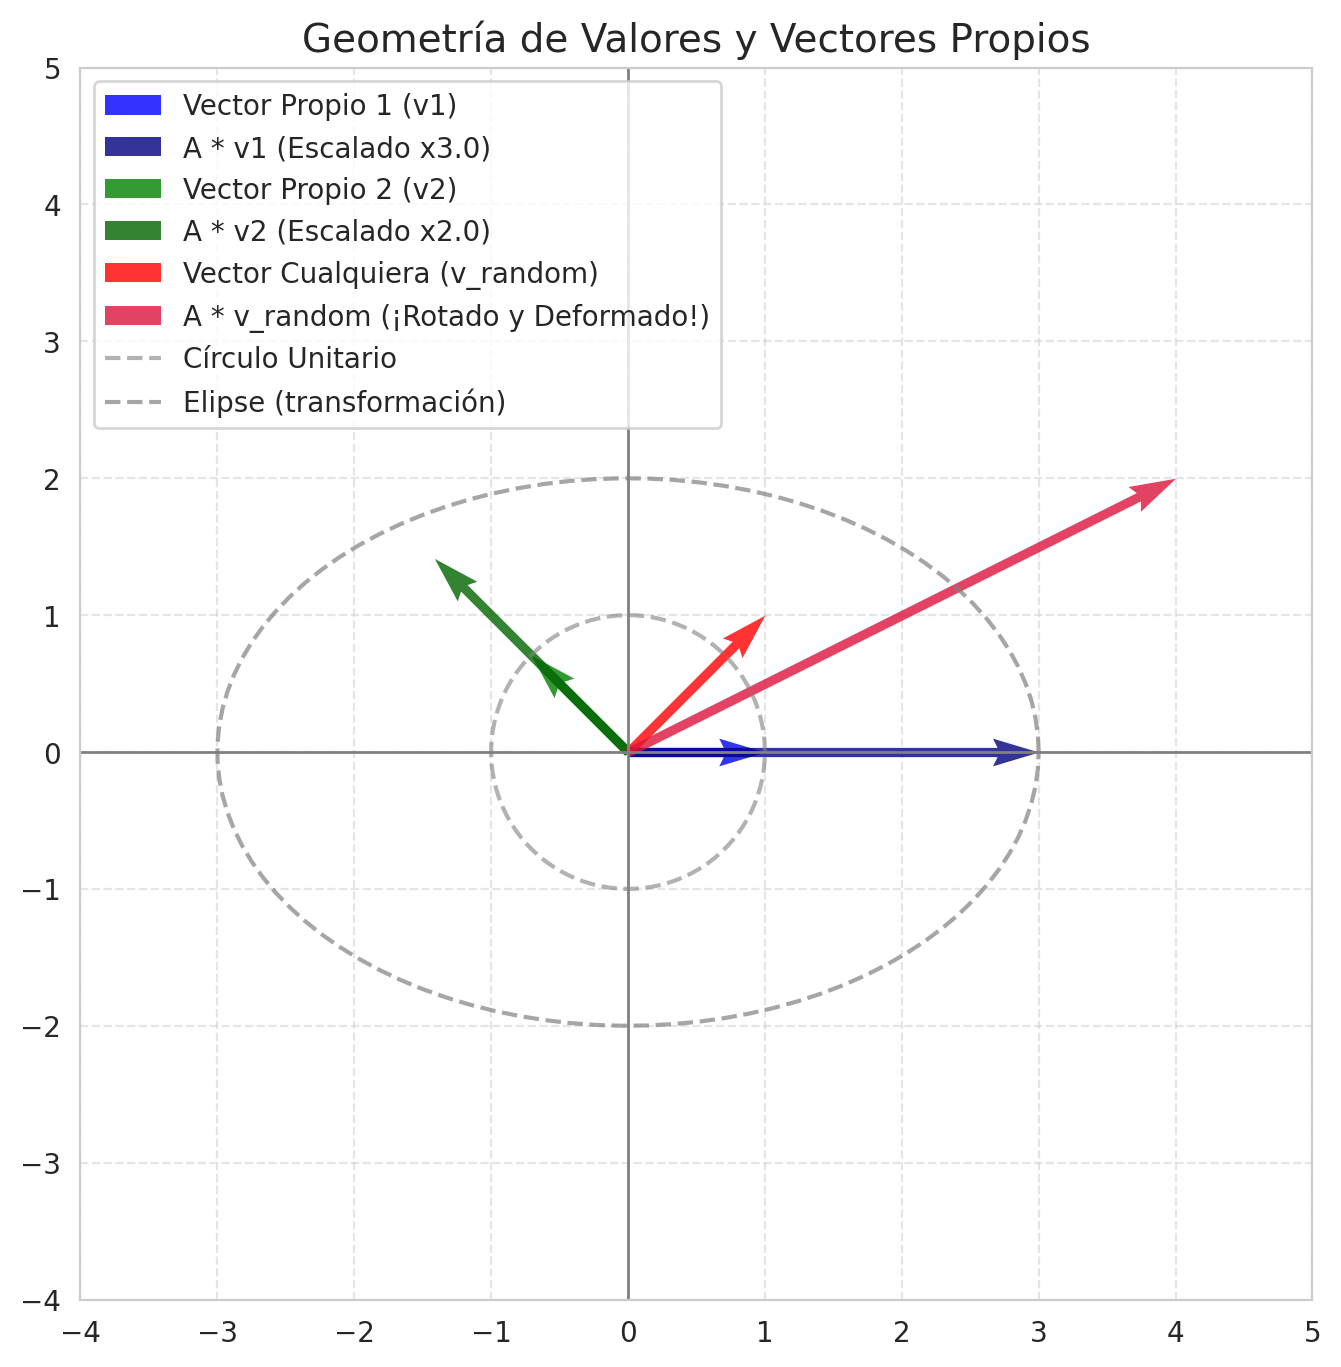

In [ ]:
#@title Interpretación geométrica

# 1. Definimos una matriz de transformación de 2x2
# Esta matriz estira el espacio de una forma particular
A = np.array([[3, 1],
              [0, 2]])

# 2. Calculamos los valores (lambdas) y vectores propios (v)
valores_propios, vectores_propios = np.linalg.eig(A)

print("Valores propios (λ):", valores_propios)
print("Vectores propios (columnas):\n", vectores_propios)

# Extraemos los dos vectores propios (son las columnas de la matriz devuelta)
v1 = vectores_propios[:, 0]
v2 = vectores_propios[:, 1]

# Definimos un vector aleatorio cualquiera para comparar qué le pasa a un vector normal
v_random = np.array([1.0, 1.0])

# 3. Aplicamos la transformación lineal (multiplicamos la matriz por los vectores)
A_v1 = A @ v1
A_v2 = A @ v2
A_v_random = A @ v_random

# 4. Configuración del gráfico
plt.figure(figsize=(8, 8))

# Función auxiliar para dibujar las flechas (vectores)
def plot_vector(origin, vector, color, label, linestyle='-'):
    plt.quiver(*origin, *vector, angles='xy', scale_units='xy', scale=1,
               color=color, label=label, linestyle=linestyle, alpha=0.8)

# Graficamos el Vector Propio 1 (Original y Transformado)
# Notarás que el transformado es exactamente 3 veces más largo (λ = 3), en la misma línea
plot_vector([0, 0], v1, 'blue', 'Vector Propio 1 (v1)')
plot_vector([0, 0], A_v1, 'navy', f'A * v1 (Escalado x{valores_propios[0]:.1f})') # Removed linestyle

# Graficamos el Vector Propio 2 (Original y Transformado)
# Notarás que el transformado es exactamente 2 veces más largo (λ = 2), en la misma línea
plot_vector([0, 0], v2, 'green', 'Vector Propio 2 (v2)')
plot_vector([0, 0], A_v2, 'darkgreen', f'A * v2 (Escalado x{valores_propios[1]:.1f})') # Removed linestyle

# Graficamos el Vector Aleatorio (Original y Transformado)
# ¡Aquí está el truco! Este vector SÍ cambió de dirección (se rotó)
plot_vector([0, 0], v_random, 'red', 'Vector Cualquiera (v_random)')
plot_vector([0, 0], A_v_random, 'crimson', 'A * v_random (¡Rotado y Deformado!)') # Removed linestyle

### Circulo unitario
theta = np.linspace(0, 2 * np.pi, 100)
x_circle = np.cos(theta)
y_circle = np.sin(theta)
plt.plot(x_circle, y_circle, color='gray', linestyle='--', alpha=0.6, label='Círculo Unitario')

### Elipse
# Add Ellipse based on Eigenvalues and Eigenvectors
# Find the index of the largest eigenvalue
largest_eig_idx = np.argmax(valores_propios)

# Assign semi-axis lengths based on eigenvalues
major_axis_length = valores_propios[largest_eig_idx]
minor_axis_length = valores_propios[1 - largest_eig_idx] # The other eigenvalue

# Get the eigenvector corresponding to the largest eigenvalue for rotation
major_eigenvector = vectores_propios[:, largest_eig_idx]

# Calculate the angle of the major eigenvector for ellipse rotation
angle_rad = np.arctan2(major_eigenvector[1], major_eigenvector[0])

# Generate points for an ellipse aligned with standard axes (before rotation)
t = np.linspace(0, 2 * np.pi, 100)
x_ellipse_base = major_axis_length * np.cos(t)
y_ellipse_base = minor_axis_length * np.sin(t)

# Create rotation matrix
rotation_matrix = np.array([[
    np.cos(angle_rad), -np.sin(angle_rad)],
    [np.sin(angle_rad), np.cos(angle_rad)
]])

# Rotate the ellipse points
ellipse_points = rotation_matrix @ np.array([x_ellipse_base, y_ellipse_base])
plt.plot(ellipse_points[0], ellipse_points[1], color='gray', linestyle='--', alpha=0.7, label='Elipse (transformación)')


# Ajustes visuales del plano cartesiano
plt.xlim(-4, 5)
plt.ylim(-4, 5)
plt.axhline(0, color='grey', linewidth=1)
plt.axvline(0, color='grey', linewidth=1)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.gca().set_aspect('equal', adjustable='box')
plt.title('Geometría de Valores y Vectores Propios', fontsize=14)
plt.legend(loc='upper left')

# Mostrar el gráfico
plt.show()

## <font color="steelblue">Descomposición en valores y vectores propios</font>

Las descomposiciones en valores y vectores propios nos permiten escribir las matrices cuadradas en un formato que resulta más cómodo desde le punto de vista computacional cuando estamos trabajando con matrices de grandes dimensiones. Se pueden revisar las referencias presentadas para ver los diferentes tipos con los que nos podemos encontrar. Únicamente recordamos que dichas descomposiciones nos sirven para representar geométricamente vectores de n dimensiones en espacios bidimensionales o tridimensionales.

### <font color="steelblue">Descomposición de Jordan</font>

Una matriz simétrica  $\mathbf{A} = \{a_{ij}\}_{n,n}$ puede descomponerse como:

$$\mathbf{A} = \mathbf{\Gamma} \mathbf{\Delta} \mathbf{\Gamma}^T = \sum_{i=1}^n \lambda_i \mathbf{v}_i \mathbf{v}_i^t$$

donde:

$$\mathbf{\Delta} = Diag{(\lambda_1,...,\lambda_n)}$$

es una matriz diagonal con los valores propios de $\mathbf{A}$ en la diagonal, y

$$\mathbf{\Gamma} = Diag({\mathbf{v}_1,...,\mathbf{v}_n})$$

es una matriz ortogonal cuyas columnas son los vectores propios de $\mathbf{A}$.


Para matrices diagonalizables podemos utilizar las herramientas de numpy para obtener la descompisción de Jordan:

In [ ]:
# 1. Definimos la matriz en NumPy
A = np.array([[1, 0, 0],
              [0, 0.5, 0.5],
              [0, 0.5, 0.5]])

# 2. Valores y vectores propios
valores_propios, P = np.linalg.eig(A)
D = np.diag(valores_propios) # Matriz diagonal de valores propios

# 3. Verificamos la descomposición
J = P@D@P.T
J

array([[1. , 0. , 0. ],
       [0. , 0.5, 0.5],
       [0. , 0.5, 0.5]])

Dada una matriz simétrica $\mathbf{A}$ $(n \times n)$ y una función $\phi : \Re^J ⟶  \Re^J$ entonces:

$$\phi(\mathbf{A}) = \sum_{i=1}^n \phi(\lambda_i) \mathbf{v}_i \mathbf{v}_i^t$$

con $\lambda_i$ y $\mathbf{v}_i$ son respectivamente los valores y vectores propios de $\mathbf{A}$. Como consecuencia directa tenemos que:

$$\mathbf{A}^k = \mathbf{\Gamma} \mathbf{\Delta}^k \mathbf{\Gamma}^T$$

De forma inmediata tenemos que:

* $\mathbf{A}^{-1} = \mathbf{\Gamma} \mathbf{\Delta}^{-1} \mathbf{\Gamma}^T \text{ si } \mathbf{A} \text{ no singular}$

* $\mathbf{A}^{1/2} = \mathbf{\Gamma} \mathbf{\Delta}^{1/2} \mathbf{\Gamma}^T$

In [ ]:
# Obtenemos la inversa de A
Dinv = np.diag(1/valores_propios)
Ainv = P@Dinv@P.T
Ainv

array([[ 1.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  4.50359963e+15, -4.50359963e+15],
       [ 0.00000000e+00, -4.50359963e+15,  4.50359963e+15]])

In [ ]:
# Obtenemos la raiz cuadrada de A
Dsqrt = np.diag(np.sqrt(valores_propios))
Asqrt = P@Dsqrt@P.T
Asqrt

array([[1.        , 0.        , 0.        ],
       [0.        , 0.50000001, 0.49999999],
       [0.        , 0.49999999, 0.50000001]])

### <font color="steelblue">Descomposición en valores singulares</font>

La **Descomposición en Valores Singulares** (SVD, por sus siglas en inglés) es una de las factorizaciones matriciales más potentes del álgebra lineal. A diferencia de la diagonalización tradicional (que solo se aplica a matrices cuadradas), la SVD se puede calcular para **cualquier** matriz real o compleja de dimensiones $m \times n$.


Sea $A \in \mathbb{R}^{m \times n}$ una matriz real con rango $r \le \min(m, n)$. El teorema de la SVD establece que existen tres matrices $U$, $\Sigma$ y $V$ tales que la matriz $A$ se puede factorizar como:

$$A = U \Sigma V^T$$

donde:

* **$U \in \mathbb{R}^{m \times m}$ (Matriz de vectores singulares izquierdos):** Es una matriz **ortogonal**, lo que significa que $U^T U = I_m$ y $U U^T = I_m$, , con las columnas de $U$ los vectores propios de $A A^T$.

* **$V \in \mathbb{R}^{n \times n}$ (Matriz de vectores singulares derechos):** También es una matriz **ortogonal** ($V^T V = I_n$, $V V^T = I_n$), con las columnas de $V$ los vectores propios de $A^T A$.

* **$\Sigma \in \mathbb{R}^{m \times n}$ (Matriz de valores singulares):** Es una matriz diagonal por bloques. Sus elementos no diagonales son estrictamente cero. Los elementos de la diagonal principal, denotados como $\sigma_i$, se llaman **valores singulares** y se ordenan de mayor a menor de forma unívoca:

$$\sigma_1 \ge \sigma_2 \ge \dots \ge \sigma_r > \sigma_{r+1} = \dots = \sigma_{\min(m,n)} = 0$$

que se corresponden con las raices cuadradas de los valores popios distintos de cero de $A^T A$.


La SVD permite expresar a la matriz $A$ no solo como producto, sino como una **combinación lineal de matrices de rango 1** (producto externo de vectores):

$$A = \sum_{i=1}^{r} \sigma_i u_i v_i^T$$

Si truncamos esta suma en los primeros $k$ términos ($k < r$), construimos una aproximación de rango $k$ a la que llamamos $A_k$:

$$A_k = \sum_{i=1}^{k} \sigma_i u_i v_i^T$$

El **Teorema de Eckart-Young-Mirsky** demuestra que $A_k$ es la **mejor aproximación posible** de rango $k$ para la matriz $A$ bajo la norma de Frobenius.

In [ ]:
# Descomposición completa

# 1. Crear una matriz de ejemplo (m x n)
A = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9],
              [10, 11, 12]])

# 2. Aplicar la Descomposición en Valores Singulares
U, D, V = np.linalg.svd(A, full_matrices=False)

# Mostrar los resultados
print("Matriz U:\n", U)
print("\nValores singulares (D):\n", D)
print("\nMatriz V):\n", V)

Matriz U:
 [[-0.14087668 -0.82471435  0.53999635]
 [-0.34394629 -0.42626394 -0.65166613]
 [-0.54701591 -0.02781353 -0.31665681]
 [-0.75008553  0.37063688  0.42832658]]

Valores singulares (D):
 [2.54624074e+01 1.29066168e+00 2.40694596e-15]

Matriz V):
 [[-0.50453315 -0.5745157  -0.64449826]
 [ 0.76077568  0.05714052 -0.64649464]
 [-0.40824829  0.81649658 -0.40824829]]


Veamos la reconstrucción de la matriz original

In [ ]:
# Reconstrucción de la matriz A
np.dot(U * D, V)

array([[ 1.,  2.,  3.],
       [ 4.,  5.,  6.],
       [ 7.,  8.,  9.],
       [10., 11., 12.]])

### <font color="steelblue">Interpretación geométrica de la descomposición en valores singulares</font>

La interpretación geométrica de la descomposición en valores singulares continua con la vista para los valores y vectores propios. Imagina que comenzamos con una circunferencia o esfera unitaria perfecta en nuestro espacio de partida.

* Multiplicación por $V^T$ (Rotación o Reflexión). Dado que $V$ es una matriz ortogonal, su traspuesta $V^T$ también lo es. Las matrices ortogonales preservan las longitudes y los ángulos (son isometrías).
  * Efecto geométrico: El espacio sufre una rotación (o una reflexión).
  * Nuestra esfera unitaria no se deforma en absoluto; sigue siendo una esfera perfecta. Lo único que ocurre es que los ejes del espacio se alinean de modo que las direcciones de los vectores singulares derechos (las columnas de $V$) coincidan con los ejes coordenados estándar.

* Multiplicación por $\Sigma$ (Estiramiento puro) La matriz $\Sigma$ es diagonal y contiene los valores singulares $\sigma_i$.
  * Efecto geométrico: El espacio se estira o se encoge de forma independiente a lo largo de cada eje coordenado.
  * Aquí es donde la magia ocurre: nuestra esfera perfecta se deforma y se convierte en un elipsoide. Cada valor singular $\sigma_i$ determina exactamente la longitud de uno de los semiejes de este nuevo elipsoide. Si un valor singular es cero, el espacio se aplasta por completo en esa dirección (perdiendo una dimensión).
  
* Multiplicación por $U$ (Rotación o Reflexión final)Finalmente, nos topamos con la matriz $U$, que también es una matriz ortogonal.
  * Efecto geométrico: El elipsoide que acabamos de crear sufre una segunda rotación (o reflexión) en el espacio de llegada.
  * Esta operación no cambia la forma del elipsoide ni el largo de sus ejes ($\sigma_i$), simplemente lo orienta en su posición final dentro del nuevo espacio. Los ejes principales de este elipsoide apuntan ahora exactamente en la dirección de las columnas de $U$ (los vectores singulares izquierdos).

# <font color="darlblue">**Formas cuadráticas**</font>

Una forma cuadrática $Q(x)$ se construye a partir de una matriz $\mathbf{A} (p \times p)$ y un vector $\mathbf{x} \in \mathbb{R}^p$ como:

$$Q(x) = \mathbf{x}^T \mathbf{A} \mathbf{x} = \sum_{i=1}^p \sum_{i=1}^p a_{ij} x_i x_j$$

* Una forma cuadrática se dice definida positiva si $Q(x) > 0$ para todos los valores de $x \neq 0$.
* Una forma cuadrática se dice semidefinida positiva si $Q(x) \geq 0$ para todos los valores de $x \neq 0$.

La matriz $\mathbf{A}$ se dice definida positiva (o semidefinida positiva) si la correspondiente froma cuadrática es definida positiva (o semidefinida positiva).

## <font color="steelblue">**Resultados interesantes**</font>

* Si  $\mathbf{A} (p \times p)$ es una matriz simétrica y $Q(x)$ su correspondiente forma cuadrática, entonces existe un transformación de $y = \Gamma^T x$ de $x$ tal que

$$Q(x) = \sum_{i=1}^p \lambda_i y_i^2$$

>con $\lambda_i$ los valores propios de $\mathbf{A}$.

* $\mathbf{A}$ es definida positiva ($\mathbf{A} > 0$) si y solo si todos los $\lambda_i > 0, i=1,...,p$

* Si $\mathbf{A}$ es definida positiva ($\mathbf{A} > 0$) entonces existe $\mathbf{A}^{-1}$ y $|\mathbf{A}|>0$

* Si $\mathbf{A}$ y $\mathbf{B}$ son matrices simétricas con $\mathbf{B} > 0$, entonces el máximo en $x$ de $\frac{x^T A x}{x^T B x}$ viene dado por el mayor valor propio de $\mathbf{B}^{-1}\mathbf{A}$.

* En la situación anterior tenemos que

$$\underset{x}{max} \frac{x^T A x}{x^T B x} = \lambda_1 \geq \lambda_2 \geq .... \geq \lambda_p = \underset{x}{min} \frac{x^T A x}{x^T B x}$$

>donde $\lambda_1,...,\lambda_p$ son los valores propios de $\mathbf{B}^{-1}\mathbf{A}$

# <font color="darkblue">**Calculo diferencial**</font>

**Derivadas parciales y Jacobiano**. Si $\mathbf{x} = (x_1,...,x_k)^T$ es un vector de dimensión $k$ y $\mathbf{y}^T = (y_1,...,y_j)^T = (f_1(\mathbf{x}),...,f_j(\mathbf{x}))^T = f(\mathbf{x})$ es un vector de dimensión $j$, y $f$ es una función de $\mathbb{R}^k$ a $\mathbb{R}^j$, entonces la derivada parcial de $\mathbf{y}$ con respecto a $\mathbf{x}$ es el $j*k$ vector:

$$\frac{\partial y}{\partial x} = \left(\frac{\partial y_1}{\partial x_1},...,\frac{\partial y_j}{\partial x_1},...,\frac{\partial y_1}{\partial x_k},...,\frac{\partial y_j}{\partial x_k} \right)$$

>que se puede expresar en forma matricial (matriz jacobiana) como:

$$J_x y = \begin{bmatrix}
\frac{\partial y_1}{\partial x_1} & ... & \frac{\partial y_1}{\partial x_k}\\
...&...&...\\
\frac{\partial y_j}{\partial x_1} & ... & \frac{\partial y_j}{\partial x_k}
\end{bmatrix}$$

**Gradiente**. Si $y=f(\mathbf{x})$ es una función escalar de $\mathbf{x}$ de dimensión $k$, entonces el vector gradiente $\bigtriangledown
_x y$ viene dado por:
$$\bigtriangledown
_x y = (J_x y)^T$$

**Hessiano**. Si $y=f(\mathbf{x})$ es una función escalar de $\mathbf{x}$ de dimensión $k$, entonces la matriz Hessiano (derivadas de orden 2) viene dada por:

$$\mathbf{H}_x y = \frac{\partial^2 y}{\partial \mathbf{x} \partial \mathbf{x}^T} = \begin{bmatrix}
\frac{\partial^2 y}{\partial x_1^2} & ... & \frac{\partial^2 y}{\partial x_1\partial x_k}\\
...&...&...\\
\frac{\partial^2 y}{\partial x_k\partial x_1} & ... & \frac{\partial^2 y}{\partial x_k^2}
\end{bmatrix}$$

Con esta definición tenemos que:

$$\mathbf{H}_x y = \bigtriangledown^2
_x y = \bigtriangledown
_x\bigtriangledown
_x y$$

**Aplicaciones de cáculo**. Si $\mathbf{A}$ es una matriz de dimensiones $J \times K$ entonces:

$$\frac{\partial(\mathbf{A}\mathbf{x})}{\partial \mathbf{x}^T} = \mathbf{A}$$

$$\frac{\partial(\mathbf{x}^T\mathbf{x})}{\partial \mathbf{x}^T} = 2\mathbf{x}$$

$$\frac{\partial(\mathbf{x}^T\mathbf{A}\mathbf{x})}{\partial \mathbf{x}^T} = \mathbf{x}^T(\mathbf{A}+\mathbf{A}^T)$$

> Si $\mathbf{A}$ es simétrica
$$\frac{\partial(\mathbf{x}^T\mathbf{A}\mathbf{x})}{\partial \mathbf{x}^T} = 2\mathbf{A}\mathbf{x}$$

* El Hessiano de la forma cuadrática de $\mathbf{A}$ viene dado por:
$$\frac{\partial^2(\mathbf{x}^T\mathbf{A}\mathbf{x})}{\partial \mathbf{x}\mathbf{x}^T} = 2\mathbf{A}$$

# <font color="darkblue">**Distancia, ángulos y ortogonalidad**</font>

La distancia es un concepto relacional. Se refiere a la longitud (o norma) de la diferencia entre dos vectores. Por lo tanto, utilizamos normas y longitudes para medir la distancia entre vectores. Los conceptos de ángulo y ortogonalidad también están relacionados con la interpretación geométrica de los vectores. En el aprendizaje automático, el ángulo entre un par de vectores se utiliza como medida de similitud de vectores.

### <font color="steelblue">Definición de distancia</font>



Dados $\mathbf{x} \in \mathbb{R}^n$ e $\mathbf{y} \in \mathbb{R}^n$. Una función $d$ de $\mathbb{R}^2n$ a $\mathbb{R}_{+}$ se denomina distancia si cumple:
* $d(\mathbf{x},\mathbf{y}) > 0, \quad \forall \quad \mathbf{x} \neq \mathbf{y}$
* $d(\mathbf{x},\mathbf{y}) = 0, \quad \text{ si } \quad \mathbf{x} = \mathbf{y}$
* $d(\mathbf{x},\mathbf{y}) = d(\mathbf{x},\mathbf{z}) + d(\mathbf{z},\mathbf{y}), \quad \forall \quad  \mathbf{x}, \mathbf{y}, \mathbf{z}$


### <font color="steelblue">Distancia euclídea</font>


La distancia euclidea al cuadrado entre $\mathbf{x} \in \mathbb{R}^n$ e $\mathbf{y} \in \mathbb{R}^n$ se define como:

$$d^2(\mathbf{x},\mathbf{y})=(\mathbf{x}-\mathbf{y})^T \mathbf{A}(\mathbf{x}-\mathbf{y})$$

donde $\mathbf{A}$ es una matriz definida positiva. De forma habitual $\mathbf{A}$ se denomina métrica.

Un caso particular se da cuando $\mathbf{A} = \mathbf{I}_n$, es decir:

$$d^2(\mathbf{x},\mathbf{y})=\sum_{i=1}^n (x_i-y_i)^2 = \|x-y\|^2$$

De froma directa la distancia euclídea viene dada por el producto escalar del vector diferencia, es decir:

$$d(\mathbf{x}, \mathbf{y}) = \|x-y\| = <x-y, x-y>$$

In [ ]:
# Podemos obtener la distancia euclidea utilizando funciones anteriores
# Definición de vectores
x = np.array([1, 3, 5, 7, 9])
y = np.array([0, 2, 4, 6, 8])
# Distancia
np.linalg.norm(x-y, 2)

np.float64(2.23606797749979)

### <font color="steelblue">Interpretación geométrica</font>

El conjunto $E_d = \{ \mathbf{x} \in \mathbb{R}^n | (\mathbf{x}-\mathbf{x_0})^T (\mathbf{x}-\mathbf{x_0})=d^2\}$ representa a las esferas de radio $d$ y centro $\mathbf{x_0}$ denominadas curvas de iso-distancias desde el punto $\mathbf{x_0}$




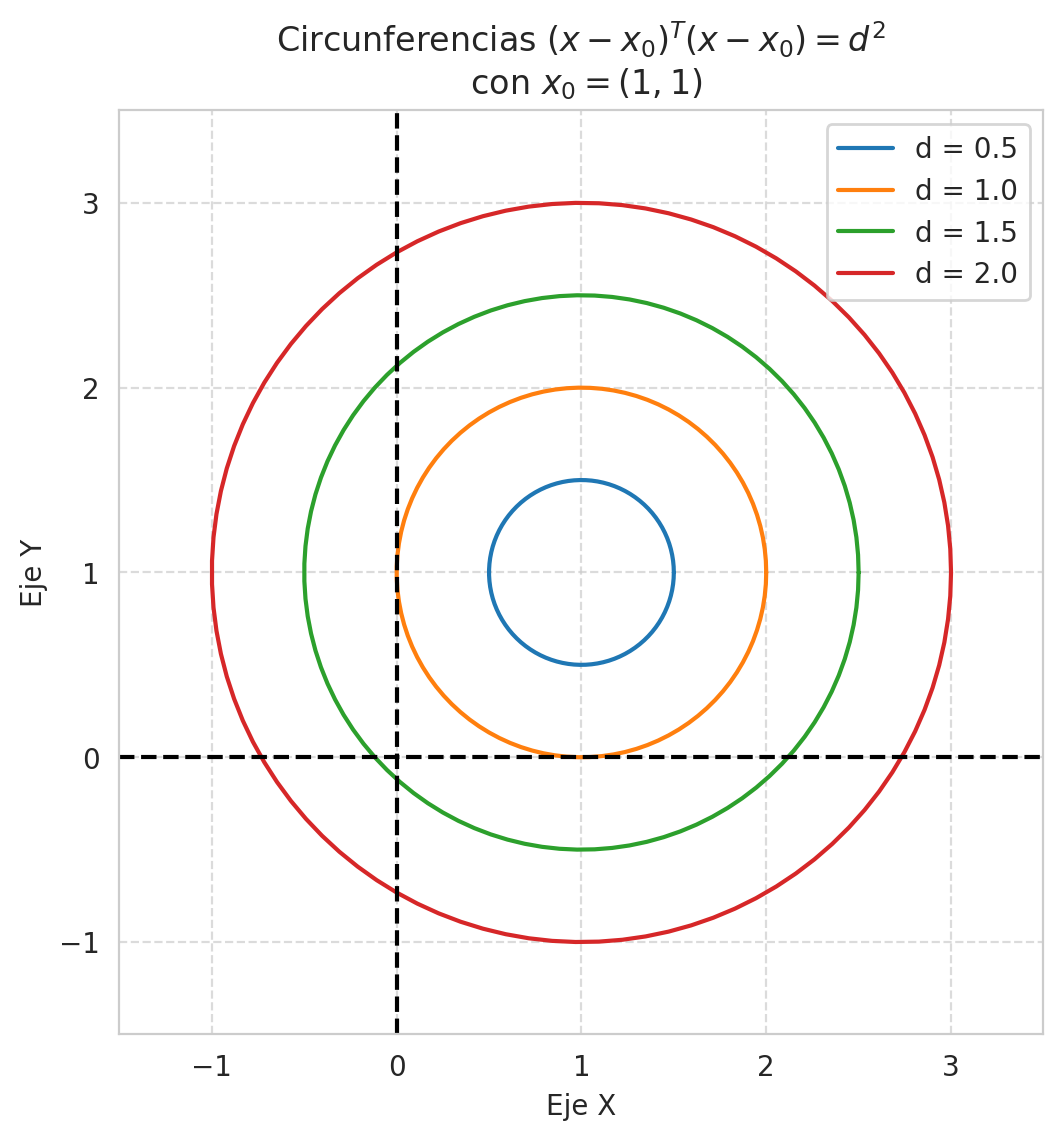

In [ ]:
#@title Regiones E_d

# Definir el centro de las circunferencias
center_x, center_y = 1, 1

# Definir una lista de radios
radii = [0.5, 1.0, 1.5, 2.0]

# Crear la figura y los ejes para el gráfico
plt.figure(figsize=(6, 6))
ax = plt.gca()

# Generar puntos para cada circunferencia y graficarlos
for r in radii:
    # Generar ángulos de 0 a 2*pi
    theta = np.linspace(0, 2 * np.pi, 100)

    # Calcular las coordenadas x e y para cada punto de la circunferencia
    x = center_x + r * np.cos(theta)
    y = center_y + r * np.sin(theta)

    # Graficar la circunferencia
    ax.plot(x, y, label=f'd = {r}')

# Configurar el gráfico
ax.set_aspect('equal', adjustable='box') # Asegura que los círculos se vean como círculos
ax.set_xlabel('Eje X')
ax.set_ylabel('Eje Y')

# Añadir líneas en los ejes de coordenadas
plt.axhline(0, color='black', linestyle='--')
plt.axvline(0, color='black', linestyle='--')

ax.set_title(f'Circunferencias $(x-x_0)^T (x-x_0) = d^2$\n con $x_0=(1,1)$')
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend()

# Establecer límites para una mejor visualización
max_radius = max(radii)
lim_min = min(center_x - max_radius - 0.5, center_y - max_radius - 0.5)
lim_max = max(center_x + max_radius + 0.5, center_y + max_radius + 0.5)
ax.set_xlim(lim_min, lim_max)
ax.set_ylim(lim_min, lim_max)
plt.show()

De forma más general el conjunto $E_d = \{ \mathbf{x} \in \mathbb{R}^n | (\mathbf{x}-\mathbf{x_0})^T \mathbf{A}(\mathbf{x}-\mathbf{x_0})=d^2\}$ con $\mathbf{A} > 0$, identifica las elipsoides con centro  $\mathbf{x_0}$ y constante $d$.

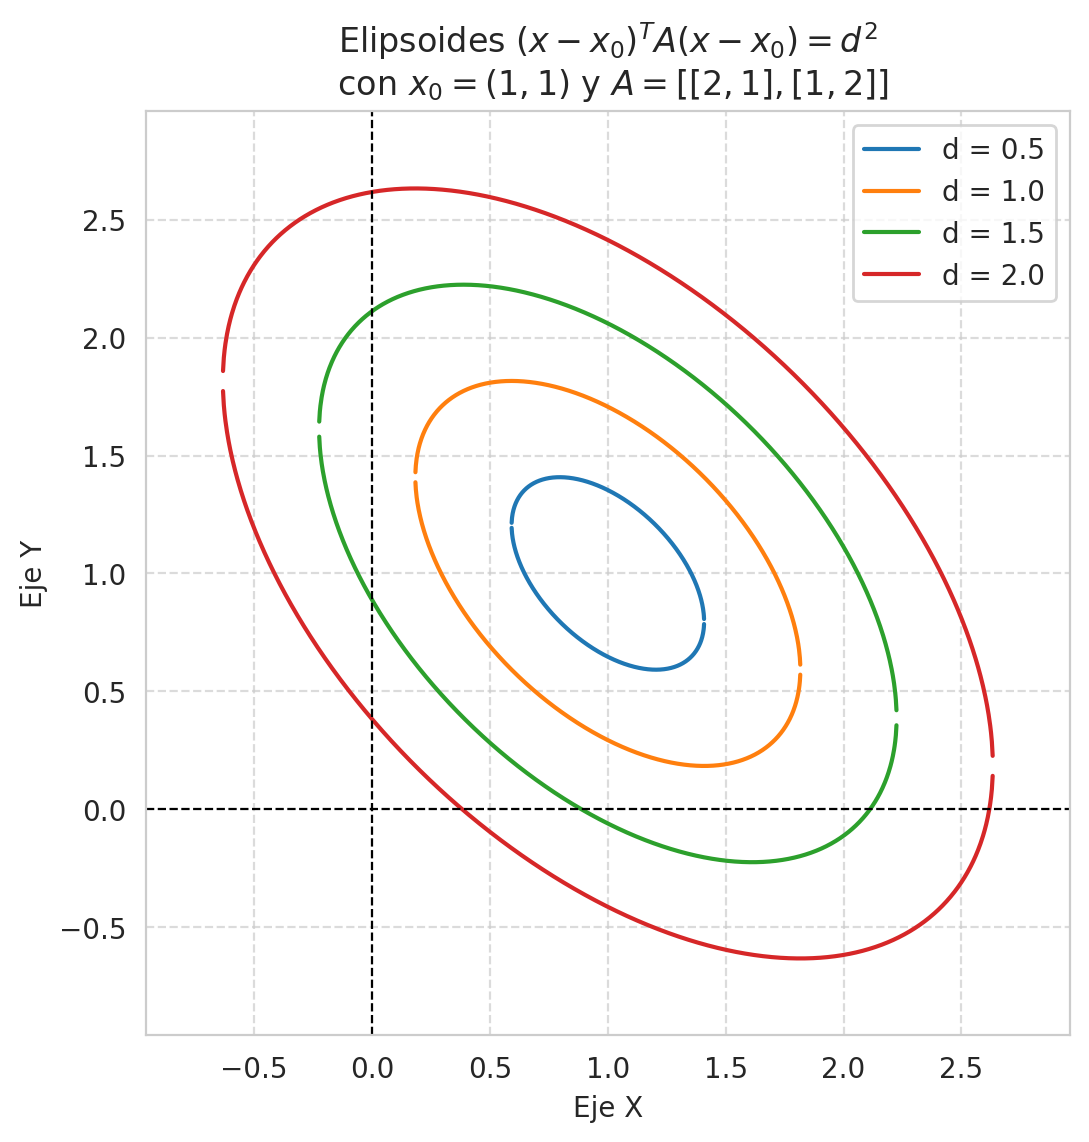

In [ ]:
#@title Elipsoides E_d

# Definir el centro
center_x, center_y = 1, 1
x0_vec = np.array([center_x, center_y])

# Definir la nueva matriz A definida positiva
A_user = np.array([[2, 1],
                   [1, 2]])

# Valores de 'd' (representando el lado derecho de la ecuación d^2)
d_values = [0.5, 1.0, 1.5, 2.0]

# Crear la figura y los ejes para el gráfico
plt.figure(figsize=(6, 6))
ax = plt.gca()

all_x_to_plot = []
all_y_to_plot = []

# Generar puntos para cada elipse y graficarlos
for d_val in d_values:
    # Ecuación es (x-x0)^T A (x-x0) = d_val^2
    # Para A = [[2,1],[1,2]], la forma expandida es:
    # 2*(x-center_x)^2 + 2*(x-center_x)*(y-center_y) + 2*(y-center_y)^2 = d_val^2

    # Sea dx = x - center_x, dy = y - center_y
    # 2*dx^2 + 2*dx*dy + 2*dy^2 = d_val^2
    # Esto es una ecuación cuadrática en dy: 2*dy^2 + (2*dx)*dy + (2*dx^2 - d_val^2) = 0

    # Rango de dx para asegurar que el discriminante sea no negativo
    # Para 2*dx^2 + 2*dx*dy + 2*dy^2 = d_val^2, el discriminante es (2*dx)^2 - 4*2*(2*dx^2 - d_val^2) = 4*dx^2 - 16*dx^2 + 8*d_val^2 = 8*d_val^2 - 12*dx^2
    # Necesitamos 8*d_val^2 - 12*dx^2 >= 0  =>  8*d_val^2 >= 12*dx^2  =>  dx^2 <= (8/12)*d_val^2  => dx^2 <= (2/3)*d_val^2
    # Por lo tanto, abs(dx) <= sqrt(2/3)*d_val
    max_abs_dx = np.sqrt(2/3) * d_val
    dx_range = np.linspace(-max_abs_dx * 1.05, max_abs_dx * 1.05, 1000) # Rango ligeramente extendido para robustez

    # Calcular dy usando la fórmula cuadrática: dy = [-B +/- sqrt(B^2 - 4AC)] / 2A
    # Aquí A_quad=2, B_quad=2*dx, C_quad=(2*dx^2 - d_val^2)
    discriminant = (2 * dx_range)**2 - 4 * 2 * (2 * dx_range**2 - d_val**2)

    # Filtrar puntos donde el discriminante es negativo (no hay soluciones reales para dy)
    valid_dx_indices = discriminant >= 0
    valid_dx_range = dx_range[valid_dx_indices]
    valid_discriminant = discriminant[valid_dx_indices]

    # Calcular las dos soluciones para dy
    dy1 = (-2 * valid_dx_range + np.sqrt(valid_discriminant)) / 4
    dy2 = (-2 * valid_dx_range - np.sqrt(valid_discriminant)) / 4

    # Convertir de regreso a coordenadas x, y
    x_coords = center_x + valid_dx_range
    y_coords1 = center_y + dy1
    y_coords2 = center_y + dy2

    # Graficar las dos ramas de la elipse
    ax.plot(x_coords, y_coords1, label=f'd = {d_val}')
    ax.plot(x_coords, y_coords2, color=ax.lines[-1].get_color()) # Usar el mismo color para ambas ramas

    all_x_to_plot.extend(x_coords)
    all_y_to_plot.extend(y_coords1)
    all_y_to_plot.extend(y_coords2)

# Configurar el gráfico
ax.set_aspect('equal', adjustable='box') # Intentar mantener la proporción
ax.set_xlabel('Eje X')
ax.set_ylabel('Eje Y')

# Añadir líneas en los ejes de coordenadas (en el centro 0,0)
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)

ax.set_title(f'Elipsoides $(x-x_0)^T A (x-x_0) = d^2$\n con $x_0=(1,1)$ y $A=[[2,1],[1,2]]$')
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend()

# Ajustar límites para una mejor visualización de las elipses
if all_x_to_plot and all_y_to_plot:
    min_x_plot, max_x_plot = np.min(all_x_to_plot), np.max(all_x_to_plot)
    min_y_plot, max_y_plot = np.min(all_y_to_plot), np.max(all_y_to_plot)

    # Añadir un poco de padding
    padding_x = (max_x_plot - min_x_plot) * 0.1
    padding_y = (max_y_plot - min_y_plot) * 0.1

    ax.set_xlim(min_x_plot - padding_x, max_x_plot + padding_x)
    ax.set_ylim(min_y_plot - padding_y, max_y_plot + padding_y)
else:
    # Fallback limits if no points were plotted for some reason
    ax.set_xlim(center_x - 3, center_x + 3)
    ax.set_ylim(center_y - 3, center_y + 3)

plt.show()

Si $\gamma_1,\gamma_2,...,\gamma_n$ son los vectores propios ortonormales (ortoganles de norma 1) de $\mathbf{A}$ correspondientes a los valores propios $\lambda_1 \geq \lambda_2 \geq ... \geq \lambda_n$ entonce se verifica para las elipsoides del conjunto $E_d$ que:

* Los ejes principales de $E_d$ están en la dirección de $\gamma_i$, $i=1,...,n$
* Las semilongitudes de los ejes son $\sqrt{\frac{d^2}{\lambda_i}}$, $i=1,...,n$
* El rectángulo que contiene a la elipse $E_d$ se define a través de las desigualdades siguientes:

$$x_{0i}-\sqrt{d^2 a^{ii}} \leq x_i \leq x_{0i}+\sqrt{d^2 a^{ii}}, \quad i=1,...,n$$

>donde $a^{ii}$ es el elemento $(i,i)$ de $\mathbf{A}^{-1}$

Estas propiedades nos proporcionan una herramienta práctica para representar elipses en dos diemensiones de una forma rápida y eficaz.

### <font color="steelblue">Ángulo entre dos vectores</font>


Dados dos vectores $\mathbf{x} \in \mathbb{R}^n$ e $\mathbf{y} \in \mathbb{R}^n$ se define el coseno del angulo ($\theta$) entre ellos como:

$$cos \theta = \frac{<x,y>}{\|x\|\|y\|}$$

In [ ]:
# Calculo del ángulo entre dos vectores
# Vectores
x = np.array([5, 1])
y = np.array([3, 5])
# Coseno del ángulo que forman
cos_theta = (np.inner(x, y)) / (np.linalg.norm(x,2) * np.linalg.norm(y,2))
# Ángulo en radianes
cos_inverse = np.arccos(cos_theta)
# Ángulo en grados
cos_inverse * ((180)/np.pi)

np.float64(47.72631099390627)

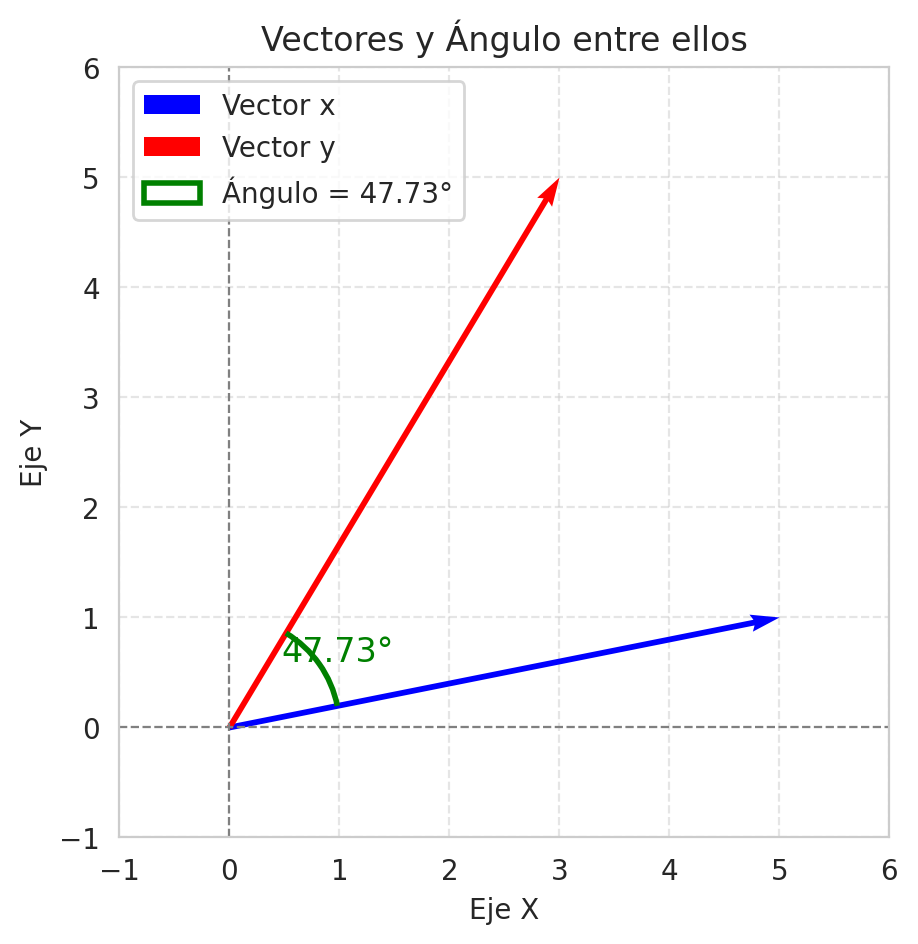

In [ ]:
#@title Rerpesentación gráfica

# Los vectores x e y ya están definidos en el estado del kernel
# x = np.array([1, 3])
# y = np.array([5, 7])
# cos_inverse (ángulo en radianes) también está disponible

plt.figure(figsize=(5, 5))
ax = plt.gca()

# Dibujar el vector x
ax.quiver(0, 0, x[0], x[1], angles='xy', scale_units='xy', scale=1, color='blue', label='Vector x')

# Dibujar el vector y
ax.quiver(0, 0, y[0], y[1], angles='xy', scale_units='xy', scale=1, color='red', label='Vector y')

# Dibujar el arco que representa el ángulo
# Calculamos el ángulo en grados para la visualización
angle_deg = np.degrees(cos_inverse)

# Coordenadas de los vectores para calcular el ángulo de inicio y fin
angle_x = np.arctan2(x[1], x[0])
angle_y = np.arctan2(y[1], y[0])

# Ajustar el arco para que siempre vaya desde el vector x al vector y en sentido antihorario
if angle_y < angle_x:
    angle_y += 2 * np.pi

arc = plt.matplotlib.patches.Arc((0, 0), 2, 2, angle=0, theta1=np.degrees(angle_x), theta2=np.degrees(angle_y), color='green', linewidth=2, label=f'Ángulo = {angle_deg:.2f}°')
ax.add_patch(arc)

# Añadir texto con el valor del ángulo
# Calcular una posición para el texto del ángulo
mean_angle_rad = (angle_x + angle_y) / 2
# Asegurar que el radio del texto sea un poco mayor que el del arco para que no se superponga
text_radius = 1.2 # Adjust as needed
angle_text_x = text_radius * np.cos(mean_angle_rad)
angle_text_y = text_radius * np.sin(mean_angle_rad)
ax.text(angle_text_x, angle_text_y, f'{angle_deg:.2f}°', color='green', fontsize=12, ha='center', va='center')


# Configurar el gráfico
ax.set_xlim(min(0, x[0], y[0]) - 1, max(x[0], y[0]) + 1)
ax.set_ylim(min(0, x[1], y[1]) - 1, max(x[1], y[1]) + 1)
ax.set_xlabel('Eje X')
ax.set_ylabel('Eje Y')
ax.set_title('Vectores y Ángulo entre ellos')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_aspect('equal', adjustable='box')
ax.legend(loc='upper left')

plt.show()

De forma general el águlo entre dos vectores $\mathbf{x} \in \mathbb{R}^n$ e $\mathbf{y} \in \mathbb{R}^n$ se pùede definir con respecto a una métrica $\mathbf{A}$ como:

$$cos \theta = \frac{x^T A y}{\|x\|_A\|y\|_A}$$

### <font color="steelblue">Ortogonalidad entre dos vectores</font>


La ortogonalidad suele utilizarse indistintamente con la "independencia", aunque son conceptos matemáticamente diferentes. La ortogonalidad puede verse como una generalización de la perpendicularidad a los vectores en cualquier número de dimensiones.

Decimos que un par de vectores $\mathbf{x} \in \mathbb{R}^n$ e $\mathbf{y} \in \mathbb{R}^n$ son ortogonales si su producto escalar es cero:

$$<x, y>= x^T y= 0.$$

Utilizando la definición de ángulo, si el producto escalar entre los dos vectores es igual a cero implica que el ángulo que se forma entre ambos es de 90 grados.

### <font color="steelblue">Proyecciones</font>

Dados dos vectores $\mathbf{x} \in \mathbb{R}^n$ e $\mathbf{y} \in \mathbb{R}^n$ ortogonales, es decir, $\mathbf{x}^T \mathbf{y} = 0$, se define la proyección $\|p_x\|$ del vector $\mathbf{x}$ sobre el vector $\mathbf{y}$ como:

$$\|p_x\| = \frac{|\mathbf{x}^T \mathbf{y}|}{\|\mathbf{y}\|}$$

In [ ]:
# Vectores
x = np.array([3, 3])
y = np.array([0, 5])
# ProyecciónCalculate
px = (np.inner(x, y)) / (np.linalg.norm(y,2))
print(f"Vector x: {x}")
print(f"Vector y: {y}")
print(f"Proyección escalar de x sobre y (px): {px:.2f}")

Vector x: [3 3]
Vector y: [0 5]
Proyección escalar de x sobre y (px): 3.00


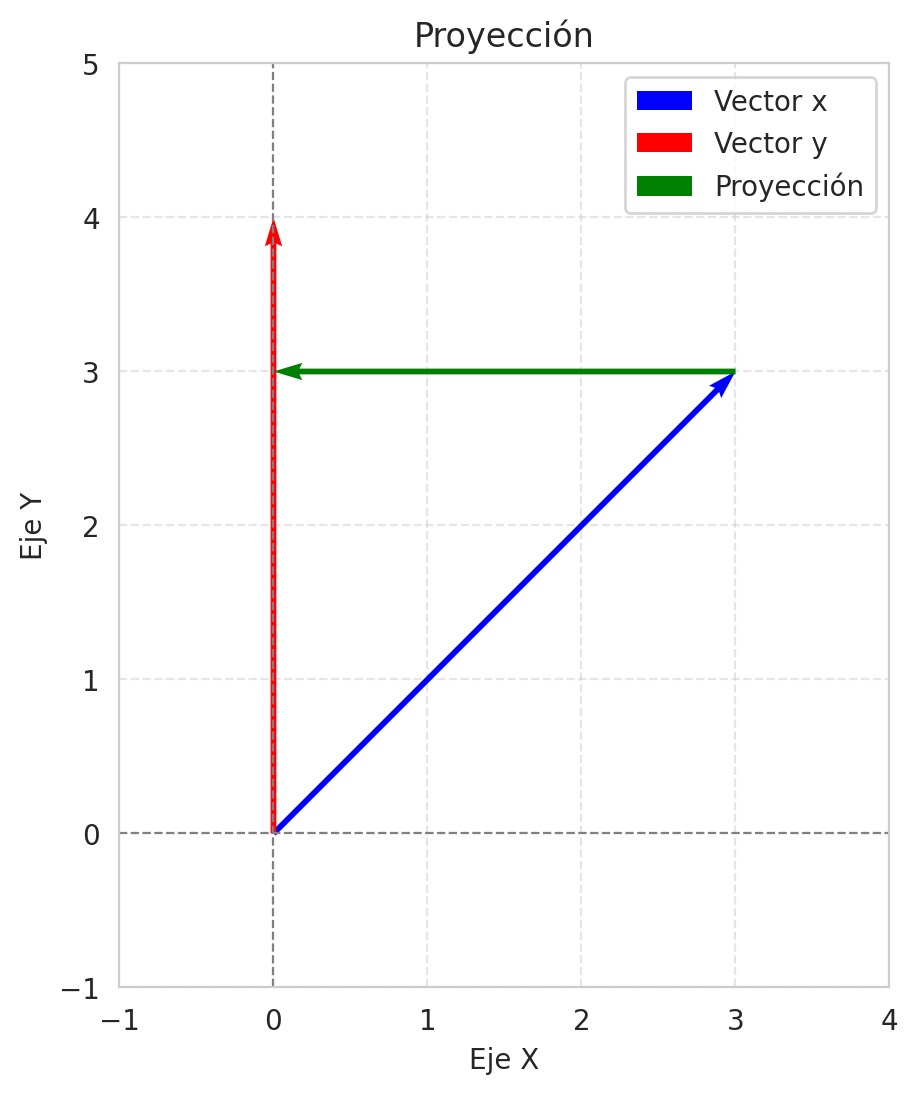

In [ ]:
#@title Rerpesentación gráfica de la proyección
x = np.array([3, 3])
y = np.array([0, 4])
plt.figure(figsize=(6, 6))
ax = plt.gca()

# Dibujar el vector x
ax.quiver(0, 0, x[0], x[1], angles='xy', scale_units='xy', scale=1, color='blue', label='Vector x')
# Dibujar el vector y
ax.quiver(0, 0, y[0], y[1], angles='xy', scale_units='xy', scale=1, color='red', label='Vector y')
# Proyección
ax.quiver(3, 3, -3, 0, angles='xy', scale_units='xy', scale=1, color='green', label='Proyección')
# Configurar el gráfico
ax.set_xlim(min(0, x[0], y[0]) - 1, max(x[0], y[0]) + 1)
ax.set_ylim(min(0, x[1], y[1]) - 1, max(x[1], y[1]) + 1)
ax.set_xlabel('Eje X')
ax.set_ylabel('Eje Y')
ax.set_title('Proyección')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_aspect('equal', adjustable='box')
ax.legend(loc='upper right')
plt.show()


#### <font color="steelblue">Matriz de proyección</font>

Una matriz $\mathbf{P}$ de dimensiones $(n × n)$ se denomina matriz de proyección (ortogonal) en $\mathbb{R}^n$ si y solo si $\mathbf{P} = \mathbf{P}^T = \mathbf{P}^2$ ($\mathbf{P}$ es idempotente). Sea $b ∈ \mathbb{R}^n$. Entonces $a = \mathbf{P}b$ es la proyección de $b$ sobre $C(\mathbf{P})$.

Dada una matriz $\mathbf{X}(n×p)$ se definen las matrices

$$\mathbf{P} = \mathbf{X}(\mathbf{X}^T \mathbf{X})^{−1}\mathbf{X}^T$$
y
$$\mathbf{Q} = \mathbf{I}_n − \mathbf{P}.$$

Es fácil comprobar que $\mathbf{P}$ y $\mathbf{Q}$ son idempotentes y que $\mathbf{P}\mathbf{X} = \mathbf{X}$ y $\mathbf{Q}\mathbf{X} = 0$.

Como las columnas de $\mathbf{X}$ se proyectan sobre sí mismas, la matriz de proyección \mathbf{P} proyecta cualquier vector $b ∈ \mathbb{R}^n$ sobre $C(\mathbf{X})$. De forma similar, la matriz de proyección \mathbf{Q} proyecta cualquier vector $b ∈ \mathbb{R}^n$ sobre el complemento ortogonal de $C(\mathbf{X})$.

In [ ]:
# Matriz en R2
X = np.array([[2, 1],
              [-3, -1]])
# Vector a proyectar
y = np.array([0, 2])
# Matrices de proyección
P = X @ np.linalg.inv(X.T @ X) @ X.T
Q = np.identity(X.shape[0])- P
# Resultados
print("Matriz X", X, sep="\n")
print("Vector y", y, sep="\n")
print("Matriz P", P, sep="\n")
print("Matriz Q", Q, sep="\n")
print("Proyección de b sobre C(X)", P@y, sep="\n")
print("Proyección de b sobre el complemento ortogonal de C(X)", Q@y, sep="\n")

Matriz X
[[ 2  1]
 [-3 -1]]
Vector y
[0 2]
Matriz P
[[1.00000000e+00 8.88178420e-16]
 [1.77635684e-15 1.00000000e+00]]
Matriz Q
[[ 0.00000000e+00 -8.88178420e-16]
 [-1.77635684e-15  1.77635684e-15]]
Proyección de b sobre C(X)
[1.77635684e-15 2.00000000e+00]
Proyección de b sobre el complemento ortogonal de C(X)
[-1.77635684e-15  3.55271368e-15]


### <font color="steelblue">Rotaciones</font>

Cuando consideramos un punto $x ∈ \mathbb{R}^p$, generalmente usamos un sistema de p-coordenadas para obtener
su representación geométrica (base en $\mathbb{R}^p$). Sin embargo como veremos más adelante habrá situaciones
donde querremos rotar este sistema de coordenadas un ángulo θ.

Consideremos, por ejemplo, el punto $P$ con coordenadas $x = (x_1, x_2)$ en $\mathbb{R}^2$ con respecto a un sistema de ejes ortogonales dado (base canñocica por ejemplo). Sea $\Gamma$ una matriz ortogonal de dimensiones $(2 × 2)$ donde

$$\Gamma = \begin{bmatrix}
cos θ & sin θ\\
−sin θ & cos θ\\
\end{bmatrix}$$

Si los ejes giran alrededor del origen un ángulo θ en sentido horario, las nuevas coordenadas de $P$ vendrán dadas por el vector
$$y = \Gamma x,$$
y una rotación del mismo ángulo en sentido antihorario da las nuevas
coordenadas como
$$y = \Gamma^T x,$$

De forma más general, premultiplicar un vector $x$ por una matriz ortogonal corresponde geométricamente a una rotación del sistema de ejes, de modo que el primer eje nuevo está
determinado por la primera fila de $\Gamma$.

In [ ]:
# Matriz en R2
X = np.array([[2, 1],
              [-3, -1]])
# Angulo
theta = 30 * np.pi / 180
# Matriz de rotación
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta), np.cos(theta)]])

# Rotacion en sentio horario
y1 = R @ X
# Rotacion en sentio antihorario
y2 = R.T @ X

print("Matriz X", X, sep="\n")
print("Matriz R", R, sep="\n")
print("Rotacion en sentido horario", y1, sep="\n")
print("Rotacion en sentido antihorario", y2, sep="\n")
#

Matriz X
[[ 2  1]
 [-3 -1]]
Matriz R
[[ 0.8660254 -0.5      ]
 [ 0.5        0.8660254]]
Rotacion en sentido horario
[[ 3.23205081  1.3660254 ]
 [-1.59807621 -0.3660254 ]]
Rotacion en sentido antihorario
[[ 0.23205081  0.3660254 ]
 [-3.59807621 -1.3660254 ]]


# <font color="darkblue">**Manipulación estadística de la matriz de datos**</font>

## <font color="steelblue">Estadísticos muestrales</font>

A partir de ahora la matriz $\mathbf{X}$ de dimensiones $n \times p$ representa $n$ realizaciones muestrales de un vector $p$ dimensional, es decir, de $p$ características recogidas para cada uno de los $n$ sujetos:

$$\mathbf{X} =
\begin{bmatrix}
x_{11} & x_{12} & ... & x_{1p}\\
x_{21} & x_{22} & ... & x_{2p}\\
... & ... & ... & ...\\
x_{n1} & x_{n2} & ... & x_{np}
\end{bmatrix}
$$

* Se define el vector de medias $\bar{\mathbf{x}}$ de $\mathbf{X}$ a partir de la medias de cada una de las $p$ componentes como $\bar{x}_1,...,\bar{x}_p$ que se puede escribir en forma matricial como:

$$\bar{\mathbf{x}} = \begin{bmatrix}
\bar{x}_1\\
\bar{x}_2\\
... \\
\bar{x}_p
\end{bmatrix} = n^{-1} \mathbf{X}^T \mathbf{1}_n$$

* Se define la matriz de covarianzas $\mathbf{S}$ de $\mathbf{X}$ como:

$$\mathbf{S} = n^{-1} \mathbf{X}^T \mathbf{X} - \bar{\mathbf{x}}\bar{\mathbf{x}}^T = n^{-1}\mathbf{X}^T \mathbf{H}\mathbf{X} $$

>con $\mathbf{H}$ la matriz de centrado que viene dado por la expresión:

$$\mathbf{H} = \mathbf{I}_n - n^{-1}\mathbf{1}_n\mathbf{1}_n^T$$

>El estimador insesgado de la matriz de covarianzas $\mathbf{S}_u$ viene dado por:

$$\mathbf{S}_u = \frac{n}{n-1}\mathbf{S}$$

* Se define la matriz de correlaciones $\mathbf{R}$ de $\mathbf{X}$ como:

$$\mathbf{R} = \mathbf{D}^{-1/2} \mathbf{S} \mathbf{D}^{-1/2}$$

>donde $\mathbf{D}^{-1/2}$ es una matriz diagonal cuyso elemntos son las desviaciones típicas de cada una de las columnas de $\mathbf{X}$.

Utilizamos el conjnto de datos siguiente

In [ ]:
# Matriz de datos
X = np.array([[230, 125, 200, 109],
     [181, 99, 55, 107],
     [165, 97, 105, 98],
     [150, 115, 85, 71],
     [97, 120, 0, 82],
     [192, 100, 150, 103],
     [181, 80, 85, 111],
     [189, 90, 120, 93],
     [172, 95, 110, 86],
     [170, 125, 130, 78]])

# Convertir la lista en un DataFrame de Pandas
columnas = ['Variable_1', 'Variable_2', 'Variable_3', 'Variable_4']
df = pd.DataFrame(X, columns=columnas)

In [ ]:
#@title Con funciones de pandas
# Calcular el Vector de Medias
vector_medias = df.mean()

# Calcular la Matriz de Varianzas y Covarianzas
# Por defecto utiliza la corrección de Bessel (n-1 en el denominador)
matriz_covarianzas = df.cov(ddof=0)

# Por defecto utiliza la corrección de Bessel (n-1 en el denominador)
matriz_covarianzas_insesgada = df.cov()

# Calcular la Matriz de Correlaciones
# Por defecto utiliza el coeficiente de Pearson
matriz_correlaciones = df.corr()

# --- Mostrar los resultados en pantalla ---
print("="*60)
print("ANÁLISIS MULTIVARIANTE CON PANDAS")
print("="*60)

print("\n Vector de Medias:")
print(vector_medias.to_string())
# .to_string() ayuda a que se visualice de forma limpia como una serie de datos

print("\n Matriz de Varianzas y Covarianzas (S):")
print(matriz_covarianzas)

print("\n Matriz de Varianzas y Covarianzas (Su):")
print(matriz_covarianzas_insesgada)

print("\n Matriz de Correlaciones (R):")
print(matriz_correlaciones)
print("="*60)

ANÁLISIS MULTIVARIANTE CON PANDAS

 Vector de Medias:
Variable_1    172.7
Variable_2    104.6
Variable_3    104.0
Variable_4     93.8

 Matriz de Varianzas y Covarianzas (S):
            Variable_1  Variable_2  Variable_3  Variable_4
Variable_1     1037.21      -80.02      1430.7      271.44
Variable_2      -80.02      219.84        92.1      -91.58
Variable_3     1430.70       92.10      2624.0      210.30
Variable_4      271.44      -91.58       210.3      177.36

 Matriz de Varianzas y Covarianzas (Su):
             Variable_1  Variable_2   Variable_3  Variable_4
Variable_1  1152.455556  -88.911111  1589.666667  301.600000
Variable_2   -88.911111  244.266667   102.333333 -101.755556
Variable_3  1589.666667  102.333333  2915.555556  233.666667
Variable_4   301.600000 -101.755556   233.666667  197.066667

 Matriz de Correlaciones (R):
            Variable_1  Variable_2  Variable_3  Variable_4
Variable_1    1.000000   -0.167576    0.867228    0.632867
Variable_2   -0.167576    1.000000

In [ ]:
#@title Con cálculo matricial
# Valores iniciales
n = df.shape[0]
Unovec = np.ones(n).reshape(n,1)
H = np.identity(n) - (1/n)*Unovec@Unovec.T

# Vector de medias
xbar = 1/n * X.T @ Unovec
print("\n Vector de Medias:")
print(xbar.reshape(1,4))

# Matriz de varianzas
S = 1/n * X.T @ H @ X
print("\n Matriz de Varianzas y Covarianzas (S):")
print(S)

# Matriz de varianzas insesgada
Su = (n/(n-1))*S
print("\n Matriz de Varianzas y Covarianzas (Su):")
print(Su)

# Matriz de correlaciones
D = np.diag(1/np.sqrt(np.diag(S)))
R = D @ S @ D
print("\n Matriz de Correlaciones (R):")
print(R)


 Vector de Medias:
[[172.7 104.6 104.   93.8]]

 Matriz de Varianzas y Covarianzas (S):
[[1037.21  -80.02 1430.7   271.44]
 [ -80.02  219.84   92.1   -91.58]
 [1430.7    92.1  2624.    210.3 ]
 [ 271.44  -91.58  210.3   177.36]]

 Matriz de Varianzas y Covarianzas (Su):
[[1152.45555556  -88.91111111 1589.66666667  301.6       ]
 [ -88.91111111  244.26666667  102.33333333 -101.75555556]
 [1589.66666667  102.33333333 2915.55555556  233.66666667]
 [ 301.6        -101.75555556  233.66666667  197.06666667]]

 Matriz de Correlaciones (R):
[[ 1.         -0.16757601  0.86722805  0.6328673 ]
 [-0.16757601  1.          0.1212619  -0.46378793]
 [ 0.86722805  0.1212619   1.          0.30826876]
 [ 0.6328673  -0.46378793  0.30826876  1.        ]]


## <font color="steelblue">Transformaciones lineales</font>

En muchas aplicaciones necesitamos estudiar transformaciones lineales de la matriz original $\mathbf{X}$.

Sea $\mathbf{A}$ matriz de dimensiones $(q \times p)$ y consideramos la transformación

$$\mathbf{Y} = \mathbf{X}\mathbf{A}^T = (\mathbf{y}_1,...,\mathbf{y}_n)^T$$

que nos proporciona una matriz de dimensiones $(n \times q)$

En esta situación tenemos que:

$$\bar{\mathbf{y}} = \frac{1}{n}\mathbf{Y}^T\mathbf{1}_n= \mathbf{A}\bar{\mathbf{x}}$$

$$\mathbf{S}_y = \mathbf{A}\mathbf{S}_x\mathbf{A}^T$$

**Aplicación 1. Efecto sombra.** Imagina que la nube de datos $\mathbf{X}$ está en 3D ($p=3$) y queremos proyectarla a un plano 2D ($q=2$) para poder reepresentar la información contenida en un gráfico en dos dimensiones.

Diseñamos una matriz de proyección $\mathbf{A}$ de $(2 \times 3)$, tal que $\mathbf{Y} = \mathbf{X}\mathbf{A}^T$ aplasta la nube 3D contra el suelo 2D.

En este caso:
* $\bar{\mathbf{y}} = \mathbf{A}\bar{\mathbf{x}}$ nos dice dónde cae la sombra del centro de la nube
* $\mathbf{S}_y = \mathbf{A}\mathbf{S}_x\mathbf{A}^T$ nos da la covarianza de la sombra. Si el elipsoide de los datos originales era muy alargado en vertical y lo miramos desde arriba, la sombra $\mathbf{S}_y$ se verá como un círculo perfecto. ¡Toda la variabilidad vertical se ha perdido (se ha aplastado)!

In [ ]:
# Matriz de datos original
X = np.array([[2, 3, 5],
     [4, 1, 10],
     [6, 5, 15]])
# Convertir la lista en un DataFrame de Pandas
columnas = ['Edad', 'Peso', 'Colesterol']
df = pd.DataFrame(X, columns=columnas)
# Estimaciones de X
xbar = df.mean()
xsigma = df.cov()
print("\n Vector de Medias (X):")
print(xbar.to_string())
print("\n Matriz de Varianzas y Covarianzas (S, X):")
print(xsigma)

# Matriz de transformación
# Queremos "aplastar" estos datos en un plano bidimensional ($q=2$), por ejemplo,
# quedándonos solo con la Edad y el Peso, eliminando por completo el Colesterol.
A = np.array([[1, 0, 0],
     [0, 1, 0]])
Y = X @ A.T
# Convertir la lista en un DataFrame de Pandas
columnas = ['Edad', 'Peso']
dfy = pd.DataFrame(Y, columns=columnas)
# Estimaciones de X
ybar = A@xbar
ysigma = A@xsigma@A.T
print("\n Vector de Medias (Y):")
print(ybar)
print("\n Matriz de Varianzas y Covarianzas (S, Y):")
print(ysigma)


 Vector de Medias (X):
Edad           4.0
Peso           3.0
Colesterol    10.0

 Matriz de Varianzas y Covarianzas (S, X):
            Edad  Peso  Colesterol
Edad         4.0   2.0        10.0
Peso         2.0   4.0         5.0
Colesterol  10.0   5.0        25.0

 Vector de Medias (Y):
[4. 3.]

 Matriz de Varianzas y Covarianzas (S, Y):
     0    1
0  4.0  2.0
1  2.0  4.0


**Aplicación 2. Cambio de escala.** Supongamos que queremos duplicar la escala de la primera característica y triplicar la de la segunda.

La matriz $\mathbf{A}$ sería una matriz diagonal:$$\mathbf{A} = \begin{pmatrix} 2 & 0 \\ 0 & 3 \end{pmatrix}$$

* $\bar{\mathbf{y}}$ duplicará la coordenada $x$ de la media y triplicará la coordenada $y$.
* Al calcular $\mathbf{S}_y = \mathbf{A}\mathbf{S}_x\mathbf{A}^T$, las varianzas en la diagonal de $\mathbf{S}_x$ se multiplicarán por $2^2=4$ y por $3^2=9$ respectivamente. Geométricamente, el elipsoide se ha estirado el doble a lo ancho y el triple a lo alto.

## <font color="steelblue">Transformaciones Mahalanobis</font>

Un caso especial de las transformaciones lineales es la denominada transformación de Mahalanobis o estandarización multivariante

$$\mathbf{z}_i = \mathbf{S}^{-1/2} (\mathbf{x}_i - \bar{\mathbf{x}})$$

En este caso la matriz resultante de la transformación:

$$\mathbf{Z} = (\mathbf{z}_1,...,\mathbf{z}_n)^T$$

verifica que:

$$\mathbf{S}_Z = n^{-1}\mathbf{Z}^T\mathbf{H}\mathbf{Z} = \mathbf{I}_p,$$

de forma que la transformación elimina la correlación entre las variables y estandariza la varianza de cada variable.

In [ ]:
# Matriz de datos
X = np.array([[230, 125, 200, 109],
     [181, 99, 55, 107],
     [165, 97, 105, 98],
     [172, 95, 110, 86],
     [170, 125, 130, 78]])

# Estimadores
xbar = np.mean(X, axis=0)
xsigma = np.cov(X, rowvar=False)
# Transformación
from scipy.linalg import sqrtm
xsigma_inv = np.linalg.inv(xsigma)
sigmainv_sqrt = sqrtm(xsigma_inv)
X_centered = X - xbar
Z = X_centered @ sigmainv_sqrt
print("Matriz de datos transformados",Z,sep="\n")
print("\nVector de medias",np.mean(Z, axis=0),sep="\n")
print("\nMatriz de correlaciones", np.corrcoef(Z),sep="\n")

Matriz de datos transformados
[[ 1.13924333  0.20620921  1.25026765  0.5444568 ]
 [ 0.71020057  0.23751381 -1.54493729  0.50236552]
 [-1.32581001 -0.49964478  0.18169068  1.07683398]
 [ 0.12733045 -1.32293816 -0.01633204 -1.19722799]
 [-0.65096434  1.37885992  0.129311   -0.92642831]]

Vector de medias
[ 1.77635684e-16 -2.22044605e-16  0.00000000e+00  3.99680289e-16]

Matriz de correlaciones
[[ 1.         -0.47330775 -0.23442539  0.96263623 -0.48635661]
 [-0.47330775  1.         -0.25754481 -0.36243757 -0.250648  ]
 [-0.23442539 -0.25754481  1.         -0.48866904 -0.25635229]
 [ 0.96263623 -0.36243757 -0.48866904  1.         -0.3558502 ]
 [-0.48635661 -0.250648   -0.25635229 -0.3558502   1.        ]]


# <font color="darkblue">**Descomposición de matrices en factores**</font>

En este apartado, adoptamos una perspectiva descriptiva y mostramos cómo el uso de un enfoque geométrico proporciona la mejor manera de reducir la dimensión de una matriz de datos.

El resultado serán representaciones gráficas de baja dimensión de la matriz de datos. Esto implica la descomposición de la matriz de datos en “factores”. Estos “factores” se ordenarán en orden decreciente de importancia.

El enfoque es muy general y constituye la idea central de muchas técnicas multivariadas. Usamos deliberadamente la palabra “factor” aquí como una herramienta o transformación para la interpretación estructural en un análisis exploratorio. En la práctica, la matriz que se descompone será alguna transformación de la matriz de datos original, y como se muestrará posteriormente, estas transformaciones facilitan la interpretación de los
gráficos obtenidos en espacios de menor dimensión.

## <font color="steelblue">La matriz desde el punto de vista geométrico</font>

Para introducir algunas ideas, supongamos que la matriz de datos $\mathbf{X} (n × p)$ está compuesta por $n$ observaciones (o individuos) de $p$ variables.

De hecho, existen dos maneras de visualizar $\mathbf{X}$: fila por fila o columna por columna:

* Cada fila (observación) es un vector $\mathbf{x}_i^T = (x_{i1}, ..., x_{ip}) ∈ \mathbb{R}^p$. Desde esta perspectiva, nuestra matriz de datos $\mathbf{X}$ se puede representar como una nube de $n$
puntos en $\mathbb{R}^p$.

* Cada columna (variable) es un vector $\mathbf{x}_{[j]} = (x_{1j}, ..., x_{nj})^T ∈ \mathbb{R}^n$. Desde esta perspectiva, la matriz de datos $\mathbf{X}$ es una nube de $p$ puntos en $\mathbb{R}^n$

Cuando $n$ y/o $p$ son grandes (mayores que 2 o 3), no podemos generar gráficos interpretables de estas nubes de puntos. Por lo tanto, el objetivo de los métodos factoriales que se desarrollarán aquí es doble. Intentaremos aproximar simultáneamente el espacio columna $C(\mathbf{X})$ y el espacio fila $C(\mathbf{X}^T)$ con subespacios más pequeños. La esperanza es, por supuesto, que esto se pueda lograr sin perder demasiada información sobre la variación y la estructura de las nubes de puntos en ambos espacios. Idealmente, esto proporcionará información sobre la estructura de $\mathbf{X}$ mediante gráficos en $\mathbb{R}$, $\mathbb{R}^2$ o $\mathbb{R}^3$. El objetivo principal es encontrar los factores de reducción de dimensionalidad.

Para ejemplificar los calculos de este punto cosideramos la matriz de datos que se presenta a continuación:

In [ ]:
X = pd.DataFrame(np.array([[230, 125, 200, 109],
     [181, 99, 55, 107],
     [165, 97, 105, 98],
     [150, 115, 85, 71],
     [97, 120, 0, 82],
     [192, 100, 150, 103],
     [181, 80, 85, 111],
     [189, 90, 120, 93],
     [172, 95, 110, 86],
     [170, 125, 130, 78]]), columns= ['V1', 'V2', 'V3', 'V4'])
X

,V1,V2,V3,V4
0,230,125,200,109
1,181,99,55,107
2,165,97,105,98
3,150,115,85,71
4,97,120,0,82
5,192,100,150,103
6,181,80,85,111
7,189,90,120,93
8,172,95,110,86
9,170,125,130,78


## <font color="steelblue">Ajuste de la nube de puntos p-dimensional</font>

### <font color="steelblue">Subespacios de dimensión 1</font>

La ​​pregunta es cómo proyectar la nube de puntos de $\mathbf{X}$ sobre un espacio de menor dimensión. Para empezar, consideremos el problema más sencillo: encontrar un subespacio de dimensión 1. El problema se reduce a encontrar una línea recta $F_1$ que pase por el origen. La dirección de esta línea se define mediante un vector unitario $u_1 ∈ \mathbb{R}^p$. Por lo tanto, buscamos el vector $u_1$ que mejor se ajuste a la nube inicial de n puntos.

La representación del i-ésimo individuo $x_i ∈ \mathbb{R}^p$ en esta línea se obtiene mediante la
proyección del punto correspondiente sobre $u_1$, es decir, el punto de proyección $p_{x_i}$. Sabemos que la coordenada de $x_i$ en $F_1$ viene dada por:

$$p_{x_i} = x_i^T\frac{u_1}{\|u_1\|} = x_i^T u_1$$

Definimos la mejor línea $F_1$ en el sentido de “mínimos cuadrados” como encontrar el vector $u_1 ∈ \mathbb{R}^p$ que minimice

$$\sum_{i=1}^n \|x_i - p_{x_i}\|^2$$

Como $\|x_i - p_{x_i}\|^2 = \|x_i\|^2 - \|p_{x_i}\|^2$ por el teorema de Pitágoras, el problema de minimizar es equivalente a maximizar

$$\sum_{i=1}^n \|p_{x_i}\|^2$$

Por lo tanto, el problema consiste en encontrar $u_1 ∈ \mathbb{R}^p$ que maximiza $\sum_{i=1}^n \|p_{x_i}\|^2$ bajo el contraste $\|u_i\| = 1$. Podemos ecribir entonces:

$$\begin{pmatrix} p_{x_1} \\ p_{x_2} \\ \vdots \\ p_{x_n}\\
\end{pmatrix} = \begin{pmatrix} x_1^T u_1 \\ x_2^T u_1 \\ \vdots \\ x_n^T u_1\\
\end{pmatrix} = \mathbf{X}u_1
$$

y el problema se reformula finalmente como:

$$\underset{u_1^T u_1 = 1}{max} u_1^T (\mathbf{X}^T \mathbf{X})u_1$$

Utilizando resultados anteriores el vector $u_1$ que resuelve el sistema es el vector propio asociado al valor propio más grande ($\lambda_1$) de la matriz $\mathbf{X}^T \mathbf{X}$.

Las coordenadas de los $n$ individuos en $F_1$ vienen dadas por $\mathbf{X}u_1$. En esta situación $\mathbf{X}u_1$ se denomina primera variable factorial o primer factor, y $u_1$, primer eje factorial. Los $n$ individuos, $x_i$, se representan ahora mediante una nueva variable factorial $z_1 = \mathbf{X}u_1$.

Esta variable factorial es una combinación lineal de las variables originales $(x_{[1]}, ..., x_{[p]})$, cuyos coeficientes vienen dados por el vector $u_1$, es decir,

$$z_1 = u_{11}x_{[1]} + ... + u_{p1}x_{[p]}.$$

Vamos a obtener la representación gráfica de la nube de puntos sobre el primer eje factorial:

In [ ]:
#@title Valores y vectores propios
# Obenemos X'X y su valores y vectores propios
Vmat = X.T @ X
eigenvalues, eigenvectors = np.linalg.eig(Vmat)
# ordenamos los valores propios y sus vectores asociados
idx = eigenvalues.argsort()[::-1]
sorted_eigenvalues = eigenvalues[idx]
sorted_eigenvectors = eigenvectors[:, idx]
print("Valores propios ordenados (mayor a menor):")
print(sorted_eigenvalues)
print("\nVectores propios ordenados (columnas):")
print(sorted_eigenvectors)

Valores propios ordenados (mayor a menor):
[6.24949707e+05 1.50457879e+04 3.97904280e+03 4.18462724e+02]

Vectores propios ordenados (columnas):
[[ 0.70172654 -0.07712492  0.40629741  0.58013277]
 [ 0.41178343 -0.45943023 -0.78695225 -0.00802613]
 [ 0.44539632  0.82170389 -0.24402135 -0.25860862]
 [ 0.37367952 -0.32829611  0.39507233 -0.77233615]]


Obtenemos ahora las coordenadas sobre $F_1$ utilizando el vector propio obtenido, y representamos gráficamente los puntos.

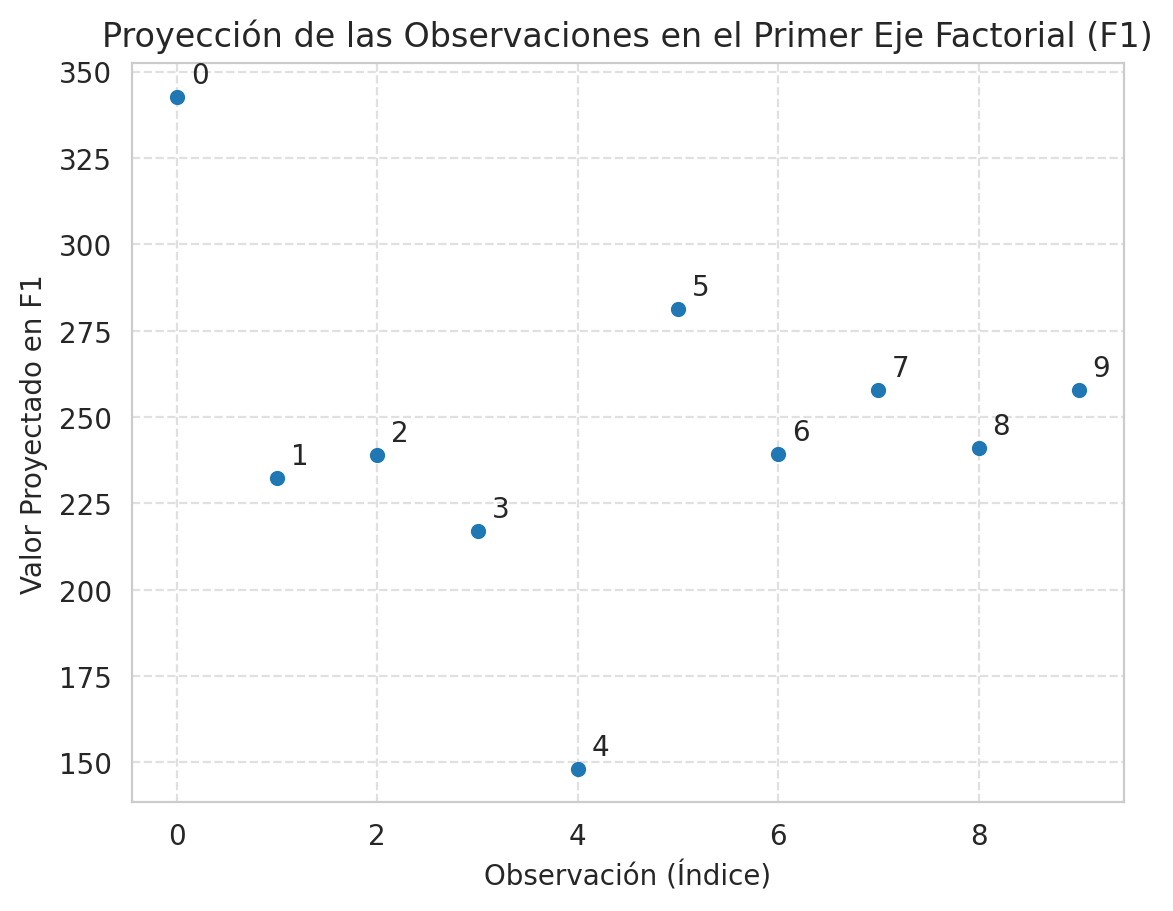

In [ ]:
#@title Proyección sobre F1
# Proyección sobre F1 de las filas de X
F1 = X @ sorted_eigenvectors[:,0]
# Convertir la Serie F1 a un DataFrame para usar kind='scatter' con x e y explícitos
# Usamos el índice de la Serie como el eje x y los valores de la Serie como el eje y
F1_df = pd.DataFrame({'Observacion_Indice': F1.index, 'Valor_Proyectado_en_F1': F1.values})
# Crear un gráfico de dispersión
ax = F1_df.plot(kind="scatter", x="Observacion_Indice", y="Valor_Proyectado_en_F1",
           title='Proyección de las Observaciones en el Primer Eje Factorial (F1)',
           xlabel='Observación (Índice)', ylabel='Valor Proyectado en F1')

# Add annotations for each point
for i, txt in enumerate(F1_df.index):
    ax.annotate(txt, (F1_df['Observacion_Indice'].iloc[i], F1_df['Valor_Proyectado_en_F1'].iloc[i]), xytext=(5, 5), textcoords='offset points')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### <font color="steelblue">Subespacios de dimensión 2</font>

Si deseamos aproximar los $n$ individuos mediante un plano (de dimensión 2), se puede demostrar,  que este espacio contiene a $u_1$. El plano está determinado por el mejor ajuste lineal ($u_1$) y un vector unitario $u_2$ ortogonal a $u_1$ que maximiza la forma cuadrática $u_2(\mathbf{X}^T \mathbf{X})u_2$ bajo las restricciones:

$$\|u_2\|=1 \quad \text{y} \quad u_1^Tu_2 = 0.$$

El vector $u_1$ que resuelve el problema de optimización es el vector propio asociado al segundo valor propio más grande ($\lambda_2$) de la matriz $\mathbf{X}^T \mathbf{X}$.

El vector unitario $u_2$ caracteriza una segunda recta, $F_2$, sobre la cual se proyectan los puntos.
Las coordenadas de los $n$ individuos en $F_2$ vienen dadas por $z_2 = \mathbf{X}u_2$.
La variable $z_2$ se denomina segunda variable factorial o segundo factor. La representación
de los $n$ individuos en un espacio bidimensional ($z_1 = \mathbf{X}u_1$ frente a $z_2 = \mathbf{X}u2$)

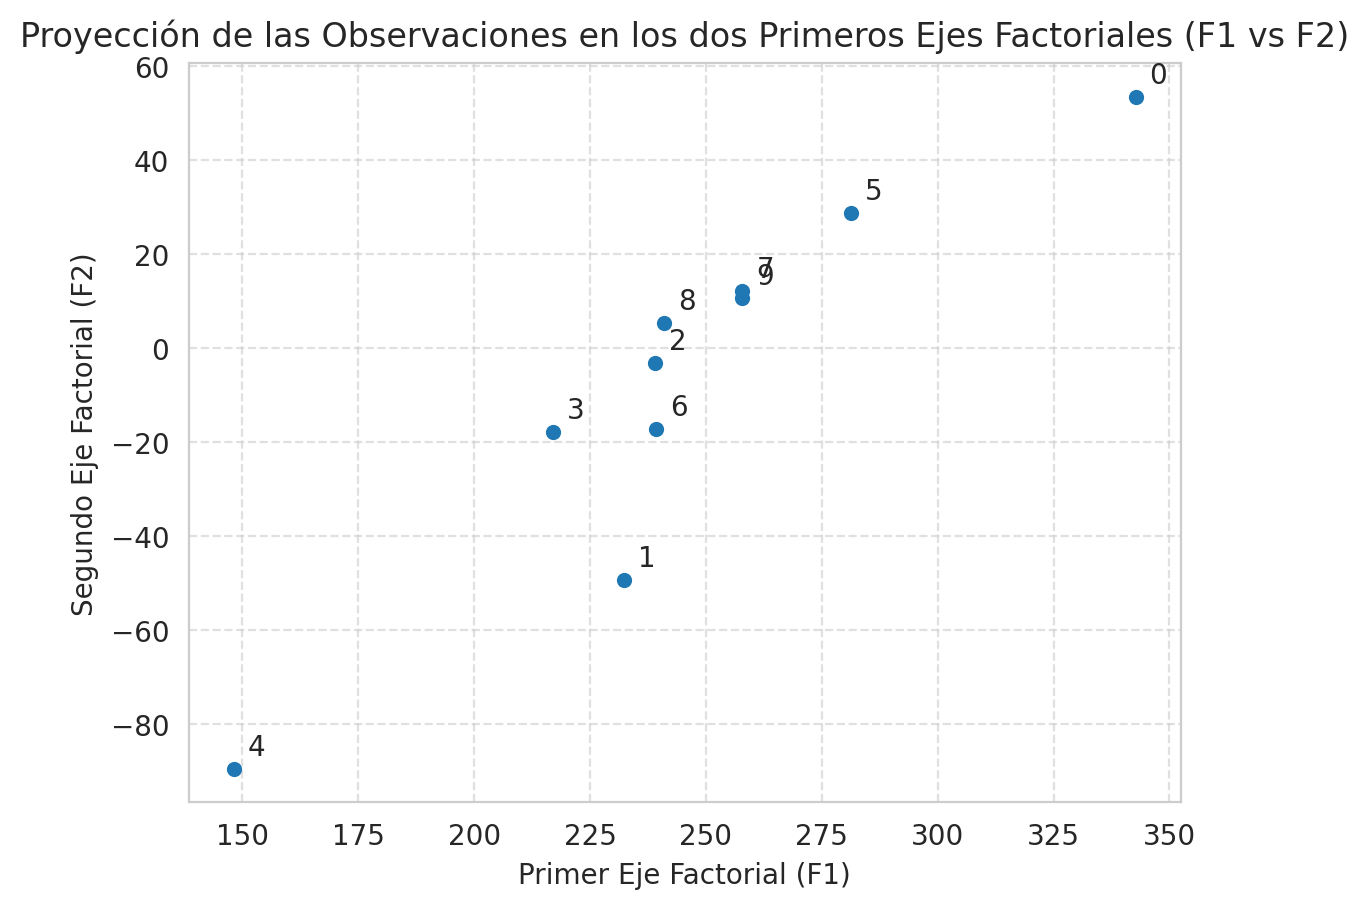

In [ ]:
#@title Proyección sobre F1 y F2
F1 = X @ sorted_eigenvectors[:,0]
F2 = X @ sorted_eigenvectors[:,1]

F1_F2_df = pd.DataFrame({'F1': F1.values, 'F2': F2.values})
# Crear un gráfico de dispersión de F1 vs F2
ax = F1_F2_df.plot(kind="scatter", x="F1", y="F2",
           title='Proyección de las Observaciones en los dos Primeros Ejes Factoriales (F1 vs F2)',
           xlabel='Primer Eje Factorial (F1)', ylabel='Segundo Eje Factorial (F2)')

# Add annotations for each point
for i, txt in enumerate(F1_F2_df.index):
    ax.annotate(txt, (F1_F2_df['F1'].iloc[i], F1_F2_df['F2'].iloc[i]), xytext=(5, 5), textcoords='offset points')

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### <font color="steelblue">Subespacios de dimensión $q$ ($q \leq p$)</font>

En el caso de $q$ dimensiones, la tarea consiste nuevamente en minimizar, pero con puntos de proyección en un subespacio q-dimensional. Usando razonamiento simialr a los casos anteriores se puede demostrar que este subespacio óptimo está generado por $u_1, u_2, ..., u_q$, los vectores propios ortonormales de $\mathbf{X}$ asociados a los autovalores correspondientes $λ_1 ≥ λ_2 ≥ ... ≥ λ_q$.

Las coordenadas de los $n$ individuos en el k-ésimo eje factorial, $u_k$, vienen dadas por la k-ésima variable factorial $z_k = Xu_k$ para $k = 1, ..., q$. Cada variable factorial $z_k = (z_{1k}, z_{2k}, ..., z_{nk})$ es una combinación lineal de las variables originales $x_{[1]}, x_{[2]}, ... , x_{[p]}$ cuyos coeficientes vienen dados por los elementos del k-ésimo vector $u_k : z_{ik} =\sum_{i=1}^p
x_{im}u_{mk}$.

## <font color="steelblue">Ajuste de la nube de puntos n-dimensional</font>

### <font color="steelblue">Subespacios de dimensión 1</font>

Supongamos que $\mathbf{X}$ está representada por una nube de $p$ puntos (variables) en $\mathbb{R}^n$ (considerando cada columna). ¿Cómo se puede proyectar esta nube en un espacio de menor dimensión?

Partimos, como antes, de una dimensión. En otras palabras, debemos encontrar una línea recta $G_1$, definida por el vector unitario $v_1 ∈ \mathbb{R}^n$, que mejor se ajuste a la nube inicial de $p$ puntos. Algebraicamente, este es el mismo problema (sustituyendo $\mathbf{X}$ por $\mathbf{X}^T$): la representación de la j-ésima variable $x_{[j]} ∈ \mathbb{R}^n$ se obtiene mediante la proyección del punto correspondiente sobre la línea recta $G_1$ o la dirección $v_1$. Por lo tanto, debemos encontrar $v_1$ tal que se maximice $\sum_{i=1}^p \|p_{x_{[j]}}^2\|$, o de forma equivalente encontrar el vector unitario $v_1$ que maximice $v_1^T (\mathbf{X}\mathbf{X}^T)$.

Por tanto, la solución a este problema es el vector propio de $\mathbf{X}\mathbf{X}^T$ correspondiente al mayor valor propio $μ_1$ de $\mathbf{X}\mathbf{X}^T$.

Las coordenadas de las p variables viene dadas por $w_1 = \mathbf{X}^T v_1.$

De foma análoga al estudio anterior podemos obteer el resto de ejes principales $G_2,...,G_q.$

/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
/usr/local/lib/python3.12/dist-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
/usr/local/lib/python3.12/dist-packages/matplotlib/text.py:1475: ComplexWarning: Casting complex values to real discards the imaginary part
/usr/local/lib/python3.12/dist-packages/matplotlib/text.py:1477: ComplexWarning: Casting complex values to real discards the imaginary part


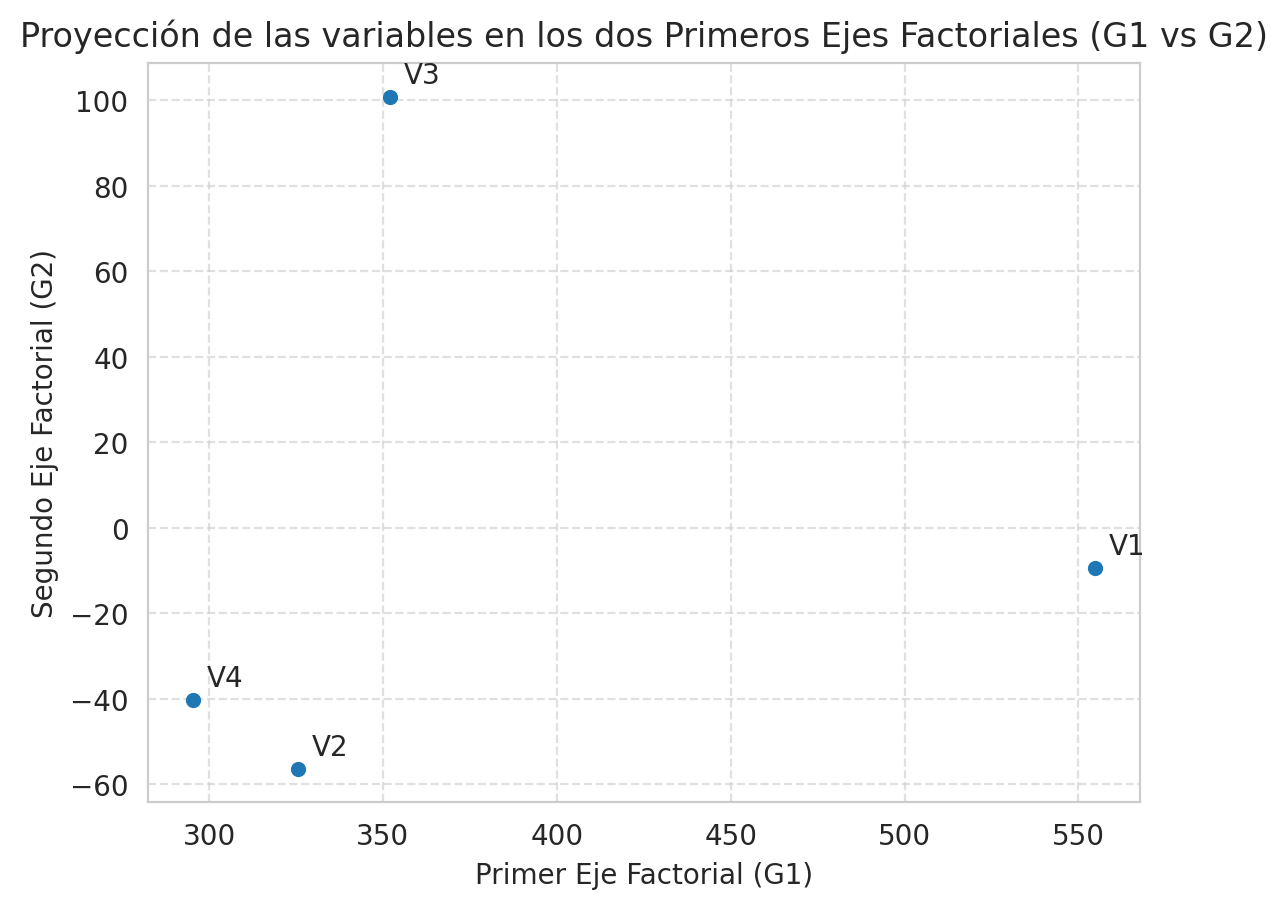

In [ ]:
#@title Representación de variables en G1 y G2
# Obenemos XX' y su valores y vectores propios
Vmat = X @ X.T
eigenvalues, eigenvectors = np.linalg.eig(Vmat)
# ordenamos los valores propios y sus vectores asociados
idx = eigenvalues.argsort()[::-1]
sorted_eigenvalues = eigenvalues[idx]
sorted_eigenvectors = eigenvectors[:, idx]

#@title Proyección sobre G1 y G2
#@title Proyección sobre F1 y F2
F1 = X.T @ sorted_eigenvectors[:,0]
F2 = X.T @ sorted_eigenvectors[:,1]

F1_F2_df = pd.DataFrame({'G1': F1.values, 'G2': F2.values})
F1_F2_df.index = X.columns
# Crear un gráfico de dispersión de F1 vs F2
ax = F1_F2_df.plot(kind="scatter", x="G1", y="G2",
           title='Proyección de las variables en los dos Primeros Ejes Factoriales (G1 vs G2)',
           xlabel='Primer Eje Factorial (G1)', ylabel='Segundo Eje Factorial (G2)')

# Add annotations for each point
for i, txt in enumerate(F1_F2_df.index):
    ax.annotate(txt, (F1_F2_df['G1'].iloc[i], F1_F2_df['G2'].iloc[i]), xytext=(5, 5), textcoords='offset points')

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## <font color="steelblue">Relación entre subespacios</font>

Si $r$ es el rango de $\mathbf{X}$, tenemos que para $k \leq r$, los valores propios $\lambda_k$ de $\mathbf{X}^T\mathbf{X}$ y $\mathbf{X}\mathbf{X}^T$ son los mismos y los vectores propios ($u_k$ y $v_k$ respectivamente) se pueden expresar como:

$$u_k = \frac{1}{\sqrt{\lambda_k}}\mathbf{X}^T v_k$$

$$v_k = \frac{1}{\sqrt{\lambda_k}}\mathbf{X} u_k$$

y la proyección de las $p$ variables sobre los ejes factoriales $v_k$ viene dada por:

$$w_k = \mathbf{X}^T v_k =\frac{1}{\sqrt{\lambda_k}}\mathbf{X}^T \mathbf{X} u_k = \sqrt{\lambda_k} u_k$$

Para proyectar sobre los ejes factoriales $G$ tan solo necesitamos los valores y vetores propios de  $\mathbf{X}^T\mathbf{X}.$

## <font color="steelblue">Calidad de la representación factorial</font>

Un aspecto fundamental de las representaciones gráficas obtenidas es conocer su grado de representatividad con respecto a los datos origiales, es decir, cuanto es capaz de explicar la representación gráfica de la relación entre muestras o variables con respecto a los datos originales.

Antes debemos introducir un concepto que nos será de mucha utilidad para interpretar de forma adecuada la calidad de la representación obtenida. Dado un vector $y \in \mathbb{R}^n$ el producto escalar $y^Ty$ se denomina inercia de $y$, actuando como una rerpesentación de la variabilidad del vector.

Si $\lambda_1 \geq \lambda_2 \geq ... \geq \lambda_k \geq ... \geq \lambda_p$ son los valores propios de $\mathbf{X}$, y $u_1,...,u_p$ los vectores propios asociados, la representación sobre los ejes factoriales viene dada por:

$$z_1 = \mathbf{X} u_1,...,z_p=\mathbf{X} u_p$$

con

$$\lambda_j = (\mathbf{X} u_j)^T(\mathbf{X} u_j) = u_j^T\mathbf{X}^T\mathbf{X}u_j = z_j^T z_j, \quad j=1,...,p.$$

De esta modo, $\lambda_j$ es al inercia asociada al j-ésimo eje factorial, y una forma estándar de evaluar la calidad de la representación factorial en un susbespacio de dimensión $k$ viene dado por el ratio:

$$\tau_k = \frac{\lambda_1 + \lambda_2 +...+\lambda_q}{\lambda_1 + \lambda_2 +...+\lambda_p}$$  

con $0 \leq \tau_k \leq 1$, que representa la cantidad de inercia explicada por los $q$ ejes factorials con respecto a la inercia total de los datos que viene dada en el denominador.

Analizamos la calidad de la representación para los dos primeros ejes factoriales en el ejemplo anterior.




In [ ]:
#@title Calidad de la representación
# Obenemos X'X y su valores y vectores propios
Vmat = X.T @ X
eigenvalues, eigenvectors = np.linalg.eig(Vmat)
# ordenamos los valores propios y sus vectores asociados
idx = eigenvalues.argsort()[::-1]
sorted_eigenvalues = eigenvalues[idx]
sorted_eigenvectors = eigenvectors[:, idx]

acumulados = np.cumsum(sorted_eigenvalues)
total = np.sum(sorted_eigenvalues)
print("Inercia explicada por cada eje factorial:")
print(np.round(sorted_eigenvalues,4))
print("Inercia explicada acumulada por cada eje factorial (en %):")
print(np.round(100*acumulados/total,2))


Inercia explicada por cada eje factorial:
[6.24949707e+05 1.50457879e+04 3.97904280e+03 4.18462700e+02]
Inercia explicada acumulada por cada eje factorial (en %):
[ 96.98  99.32  99.94 100.  ]


# <font color="darkblue">**Referencias y enlaces de interés**</font>

1. Manual online de Numpy: https://numpy.org/

2. Manual online de Scipy: https://scipy.org/

3. Mathematics for Machine Learning by Deisenroth, Faisal, and Ong. 1st Ed. [Book link](https://mml-book.github.io/).

4. Introduction to Applied Linear Algebra by Boyd and Vandenberghe. 1sr Ed. [Book link](https://web.stanford.edu/~boyd/vmls/).

5. Linear Algebra Ch. in Deep Learning by Goodfellow, Bengio, and Courville. 1st Ed. [Chapter link](https://www.deeplearningbook.org/contents/linear_algebra.html).

6. Linear Algebra Ch. in Dive into Deep Learning by Zhang, Lipton, Li, And Smola. [Chapter link](https://d2l.ai/chapter_preliminaries/linear-algebra.html).

7. Manual online de Pytorch: https://pytorch.org/

8. Manual online de TensorFlow: https://www.tensorflow.org/



# <font color="darkblue">**Para ampliar contenidos**</font>


1. Harris, C.R., Millman, K.J., van der Walt, S.J. et al. [Array programming with NumPy](https://www.nature.com/articles/s41586-020-2649-2). Nature 585, 357–362 (2020).

2. Pauli Virtanen, Ralf Gommers, Travis E. Oliphant, Matt Haberland, Tyler Reddy, David Cournapeau, Evgeni Burovski, Pearu Peterson, Warren Weckesser, Jonathan Bright, Stéfan J. van der Walt, Matthew Brett, Joshua Wilson, K. Jarrod Millman, Nikolay Mayorov, Andrew R. J. Nelson, Eric Jones, Robert Kern, Eric Larson, CJ Carey, İlhan Polat, Yu Feng, Eric W. Moore, Jake VanderPlas, Denis Laxalde, Josef Perktold, Robert Cimrman, Ian Henriksen, E.A. Quintero, Charles R Harris, Anne M. Archibald, Antônio H. Ribeiro, Fabian Pedregosa, Paul van Mulbregt, and SciPy 1.0 Contributors. (2020) [SciPy 1.0: Fundamental Algorithms for Scientific Computing in Python](https://www.nature.com/articles/s41592-019-0686-2?report=reader). Nature Methods, 17(3), 261-272.

